In [1]:
import sys
sys.path.append('../')

In [1]:
def get_connection():
    import psycopg2

    return psycopg2.connect(
        dbname="Instacart_Dw",
        user="postgres",
        password="root123"
    )

In [7]:
import io
import re
from pathlib import Path

import pandas as pd
from psycopg2 import sql

SCHEMA_NAME = "public"
SAMPLE_ROWS = 5

# 1) Read src/queries.py and extract materialized view names used there
queries_file = Path("../src/queries.py")
queries_text = queries_file.read_text(encoding="utf-8")
materialized_views = sorted(set(re.findall(r"\b(mv_[a-zA-Z0-9_]+)\b", queries_text)))

print("Materialized views referenced in src/queries.py:")
print(materialized_views)

conn = get_connection()

for mv_name in materialized_views:
    # Validate materialized view exists
    exists_q = """
    SELECT 1
    FROM pg_matviews
    WHERE schemaname = %s AND matviewname = %s;
    """
    exists_df = pd.read_sql_query(exists_q, conn, params=[SCHEMA_NAME, mv_name])

    if exists_df.empty:
        print(f"\nSkipped (not found as materialized view): {SCHEMA_NAME}.{mv_name}")
        continue

    # Load full view for proper EDA summary (shape, describe, info, missing, duplicates)
    full_q = sql.SQL("SELECT * FROM {}.{};").format(
        sql.Identifier(SCHEMA_NAME),
        sql.Identifier(mv_name),
    )
    df = pd.read_sql_query(full_q.as_string(conn), conn)

    print(f"\n===== {SCHEMA_NAME}.{mv_name} =====")

    # Basic sample
    print(f"Sample rows (top {SAMPLE_ROWS}):")
    display(df.head(SAMPLE_ROWS))

    # Shape
    print("Shape (rows, columns):", df.shape)

    # Info
    info_buffer = io.StringIO()
    df.info(buf=info_buffer)
    print("\nDataFrame info:")
    print(info_buffer.getvalue())

    # Describe
    print("Describe (all columns):")
    if df.empty:
        print("No rows in this materialized view.")
    else:
        display(df.describe(include="all").transpose())

    # Missing values
    missing_df = pd.DataFrame(
        {
            "column_name": df.columns,
            "missing_count": df.isna().sum().values,
            "missing_pct": ((df.isna().sum() / len(df)) * 100).round(2).values if len(df) > 0 else 0.0,
        }
    ).sort_values(["missing_pct", "missing_count"], ascending=[False, False])

    print("Missing values by column:")
    display(missing_df)

    # Duplicates
    duplicate_rows = int(df.duplicated().sum())
    duplicate_pct = round((duplicate_rows / len(df)) * 100, 2) if len(df) > 0 else 0.0
    duplicate_summary_df = pd.DataFrame(
        [
            {
                "table_name": mv_name,
                "total_rows": int(len(df)),
                "duplicate_rows": duplicate_rows,
                "duplicate_pct": duplicate_pct,
            }
        ]
    )

    print("Duplicate summary:")
    display(duplicate_summary_df)

conn.close()

Materialized views referenced in src/queries.py:
['mv_basket_analysis_v2', 'mv_department_performance_v2', 'mv_orders_time_v2', 'mv_overview_kpis_v2', 'mv_product_performance_v2', 'mv_reorder_department_v2', 'mv_reorder_product_v2', 'mv_reorder_time_v2']


C:\Users\geeth\AppData\Local\Temp\ipykernel_16400\3444531797.py:28: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  exists_df = pd.read_sql_query(exists_q, conn, params=[SCHEMA_NAME, mv_name])
C:\Users\geeth\AppData\Local\Temp\ipykernel_16400\3444531797.py:39: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(full_q.as_string(conn), conn)



===== public.mv_basket_analysis_v2 =====
Sample rows (top 5):


,order_id,basket_size
0,2,9
1,3,8
2,4,13
3,5,26
4,6,3


Shape (rows, columns): (3214874, 2)

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3214874 entries, 0 to 3214873
Data columns (total 2 columns):
 #   Column       Dtype
---  ------       -----
 0   order_id     int64
 1   basket_size  int64
dtypes: int64(2)
memory usage: 49.1 MB

Describe (all columns):


...

,count,mean,std,min,25%,50%,75%,max
order_hour_of_day,24.0,1.150000e+01,7.071068e+00,0.0000,5.750,1.150000e+01,1.725000e+01,2.300000e+01
total_orders,24.0,1.351437e+06,1.079358e+06,51321.0000,272833.250,1.118220e+06,2.558305e+06,2.764426e+06
reorder_count,24.0,7.969390e+05,6.344897e+05,28714.0000,169771.250,6.490060e+05,1.519160e+06,1.659507e+06
reorder_rate,24.0,5.873250e-01,2.440061e-02,0.5545,0.574,5.803000e-01,5.931000e-01,6.445000e-01


Missing values by column:


,column_name,missing_count,missing_pct
0,order_hour_of_day,0,0.0
1,total_orders,0,0.0
2,reorder_count,0,0.0
3,reorder_rate,0,0.0


Duplicate summary:


,table_name,total_rows,duplicate_rows,duplicate_pct
0,mv_reorder_time_v2,24,0,0.0


Materialized views found in src/queries.py:
['mv_basket_analysis_v2', 'mv_department_performance_v2', 'mv_orders_time_v2', 'mv_overview_kpis_v2', 'mv_product_performance_v2', 'mv_reorder_department_v2', 'mv_reorder_product_v2', 'mv_reorder_time_v2']


C:\Users\geeth\AppData\Local\Temp\ipykernel_15776\444686726.py:70: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  exists_df = pd.read_sql_query(exists_q, conn, params=[SCHEMA_NAME, mv_name])
C:\Users\geeth\AppData\Local\Temp\ipykernel_15776\444686726.py:81: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(full_q.as_string(conn), conn)



===== DISTRIBUTION ANALYSIS: public.mv_basket_analysis_v2 =====
Shape: (3214874, 2)
Numeric columns selected for analysis: ['basket_size']
Numeric distribution summary:


,count,mean,std,min,25%,50%,75%,max,iqr,cv_pct,skew
basket_size,"3,214,874.0000",10.0889,7.5254,1.0000,5.0000,8.0000,14.0000,145.0000,9.0000,74.5910,1.5590


Outlier analysis (IQR + Z-score):


,table_name,column_name,count,mean,std,q1_25pct,median_50pct,q3_75pct,iqr,iqr_lower,iqr_upper,iqr_outlier_count,iqr_outlier_pct,z_outlier_count,z_outlier_pct,skew
0,mv_basket_analysis_v2,basket_size,3214874,10.0889,7.5254,5.0000,8.0000,14.0000,9.0000,-8.5000,27.5000,105058,3.2700,48066,1.5000,1.5590


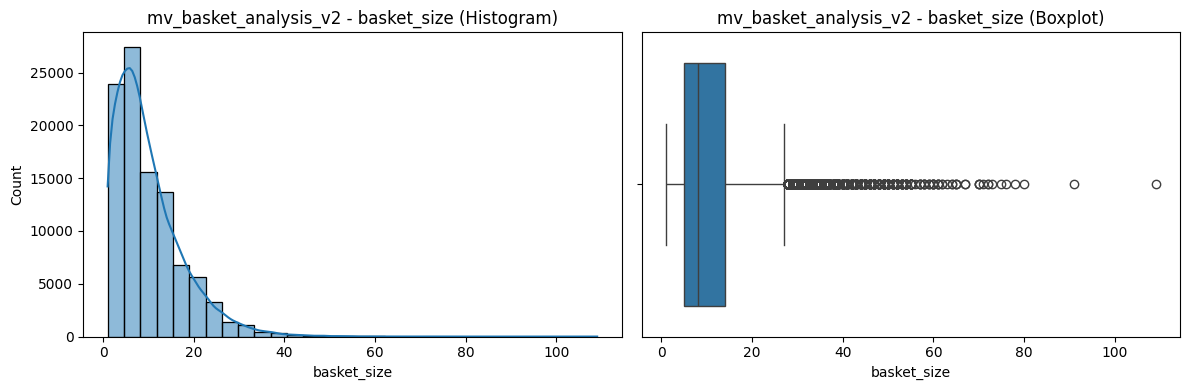


===== DISTRIBUTION ANALYSIS: public.mv_department_performance_v2 =====
Shape: (21, 3)
Numeric columns selected for analysis: ['total_orders']
Numeric distribution summary:


C:\Users\geeth\AppData\Local\Temp\ipykernel_15776\444686726.py:70: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  exists_df = pd.read_sql_query(exists_q, conn, params=[SCHEMA_NAME, mv_name])
C:\Users\geeth\AppData\Local\Temp\ipykernel_15776\444686726.py:81: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(full_q.as_string(conn), conn)


,count,mean,std,min,25%,50%,75%,max,iqr,cv_pct,skew
total_orders,21.0000,"1,544,499.4762","2,231,519.2502","34,573.0000","269,253.0000","738,666.0000","1,875,577.0000","9,479,291.0000","1,606,324.0000",144.4817,2.6802


Outlier analysis (IQR + Z-score):


,table_name,column_name,count,mean,std,q1_25pct,median_50pct,q3_75pct,iqr,iqr_lower,iqr_upper,iqr_outlier_count,iqr_outlier_pct,z_outlier_count,z_outlier_pct,skew
0,mv_department_performance_v2,total_orders,21,"1,544,499.4762","2,231,519.2502","269,253.0000","738,666.0000","1,875,577.0000","1,606,324.0000","-2,140,233.0000","4,285,063.0000",2,9.5200,1,4.7600,2.6802


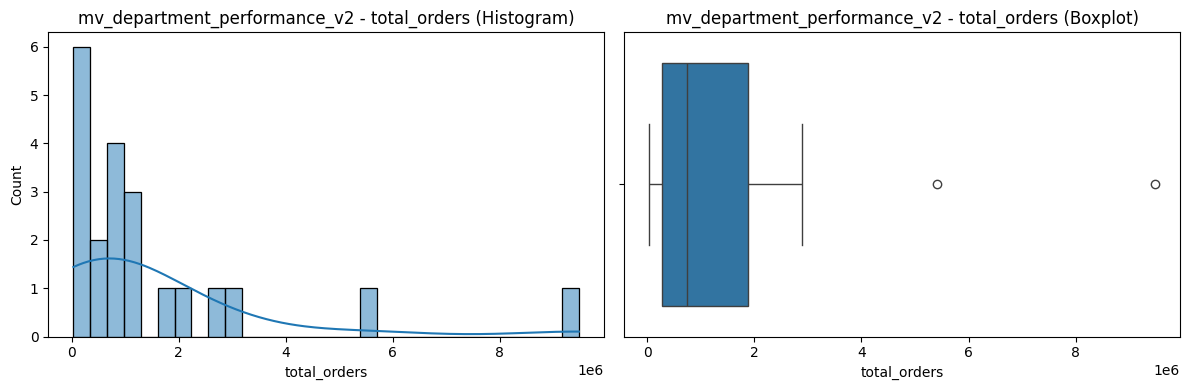


===== DISTRIBUTION ANALYSIS: public.mv_orders_time_v2 =====
Shape: (24, 2)
Numeric columns selected for analysis: ['order_hour_of_day', 'total_orders']
Numeric distribution summary:


C:\Users\geeth\AppData\Local\Temp\ipykernel_15776\444686726.py:70: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  exists_df = pd.read_sql_query(exists_q, conn, params=[SCHEMA_NAME, mv_name])
C:\Users\geeth\AppData\Local\Temp\ipykernel_15776\444686726.py:81: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(full_q.as_string(conn), conn)


,count,mean,std,min,25%,50%,75%,max,iqr,cv_pct,skew
order_hour_of_day,24.0000,11.5000,7.0711,0.0000,5.7500,11.5000,17.2500,23.0000,11.5000,61.4875,0.0000
total_orders,24.0000,"133,953.0833","107,276.4177","5,120.0000","26,937.0000","114,864.5000","256,013.2500","271,885.0000","229,076.2500",80.0851,0.1091


Outlier analysis (IQR + Z-score):


,table_name,column_name,count,mean,std,q1_25pct,median_50pct,q3_75pct,iqr,iqr_lower,iqr_upper,iqr_outlier_count,iqr_outlier_pct,z_outlier_count,z_outlier_pct,skew
0,mv_orders_time_v2,order_hour_of_day,24,11.5000,7.0711,5.7500,11.5000,17.2500,11.5000,-11.5000,34.5000,0,0.0000,0,0.0000,0.0000
1,mv_orders_time_v2,total_orders,24,"133,953.0833","107,276.4177","26,937.0000","114,864.5000","256,013.2500","229,076.2500","-316,677.3750","599,627.6250",0,0.0000,0,0.0000,0.1091


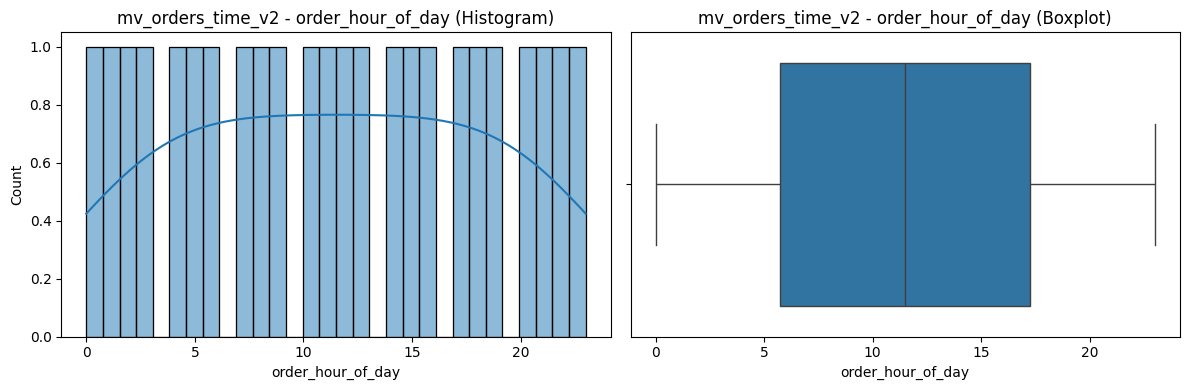

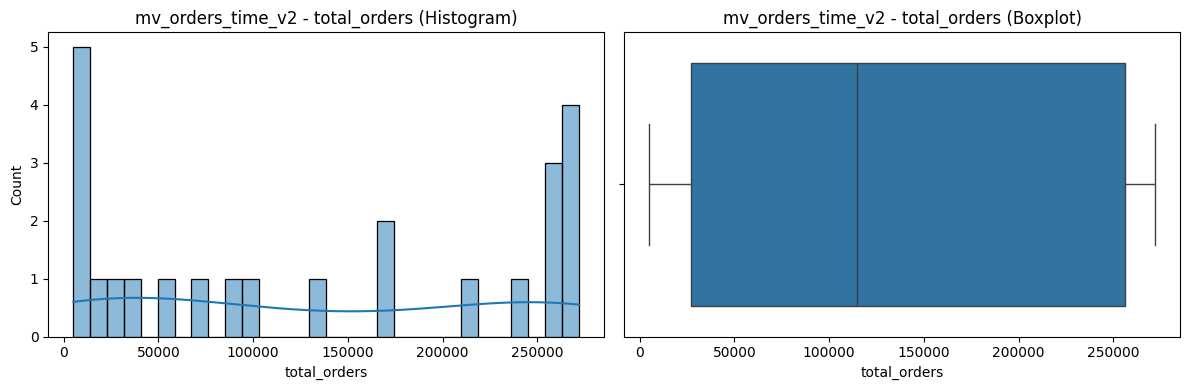


===== DISTRIBUTION ANALYSIS: public.mv_overview_kpis_v2 =====
Shape: (1, 4)
Numeric columns selected for analysis: ['total_orders', 'total_users', 'total_products', 'overall_reorder_rate']
Numeric distribution summary:


C:\Users\geeth\AppData\Local\Temp\ipykernel_15776\444686726.py:70: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  exists_df = pd.read_sql_query(exists_q, conn, params=[SCHEMA_NAME, mv_name])
C:\Users\geeth\AppData\Local\Temp\ipykernel_15776\444686726.py:81: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(full_q.as_string(conn), conn)


,count,mean,std,min,25%,50%,75%,max,iqr,cv_pct,skew
total_orders,1.0000,"3,214,874.0000",NaN,"3,214,874.0000","3,214,874.0000","3,214,874.0000","3,214,874.0000","3,214,874.0000",0.0000,NaN,NaN
total_users,1.0000,"206,209.0000",NaN,"206,209.0000","206,209.0000","206,209.0000","206,209.0000","206,209.0000",0.0000,NaN,NaN
total_products,1.0000,"49,677.0000",NaN,"49,677.0000","49,677.0000","49,677.0000","49,677.0000","49,677.0000",0.0000,NaN,NaN
overall_reorder_rate,1.0000,0.5897,NaN,0.5897,0.5897,0.5897,0.5897,0.5897,0.0000,NaN,NaN


Outlier analysis (IQR + Z-score):


,table_name,column_name,count,mean,std,q1_25pct,median_50pct,q3_75pct,iqr,iqr_lower,iqr_upper,iqr_outlier_count,iqr_outlier_pct,z_outlier_count,z_outlier_pct,skew
0,mv_overview_kpis_v2,total_orders,1,"3,214,874.0000",NaN,"3,214,874.0000","3,214,874.0000","3,214,874.0000",0.0000,"3,214,874.0000","3,214,874.0000",0,0.0000,0,0.0000,NaN
1,mv_overview_kpis_v2,total_users,1,"206,209.0000",NaN,"206,209.0000","206,209.0000","206,209.0000",0.0000,"206,209.0000","206,209.0000",0,0.0000,0,0.0000,NaN
2,mv_overview_kpis_v2,total_products,1,"49,677.0000",NaN,"49,677.0000","49,677.0000","49,677.0000",0.0000,"49,677.0000","49,677.0000",0,0.0000,0,0.0000,NaN
3,mv_overview_kpis_v2,overall_reorder_rate,1,0.5897,NaN,0.5897,0.5897,0.5897,0.0000,0.5897,0.5897,0,0.0000,0,0.0000,NaN


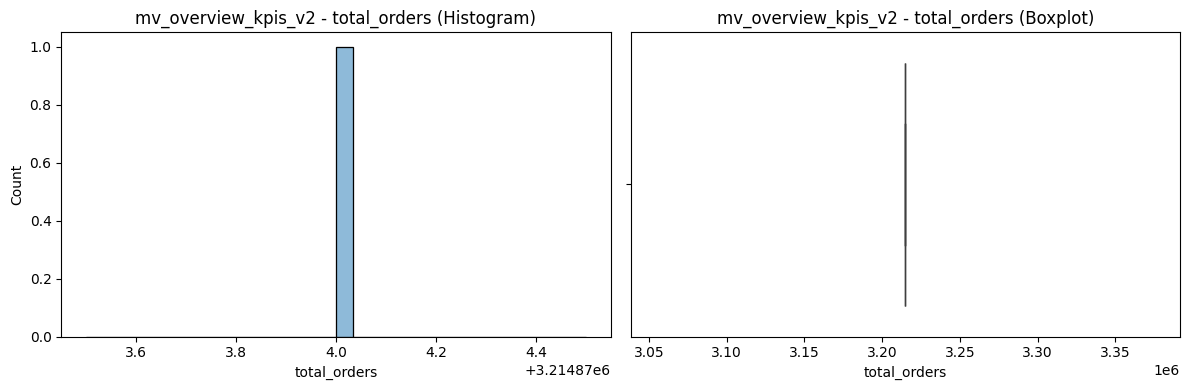

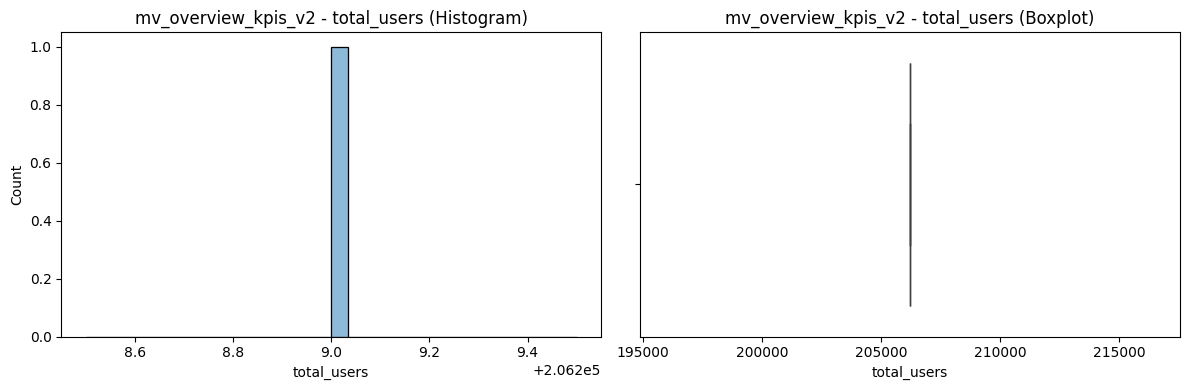

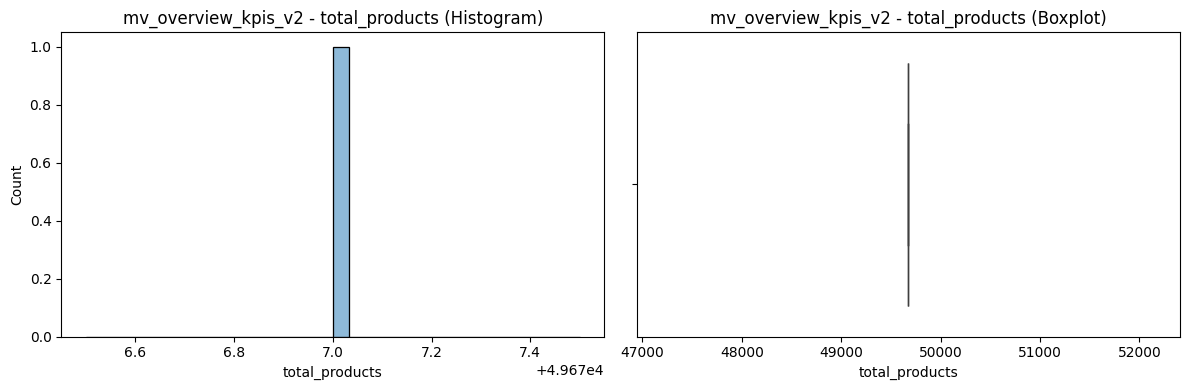

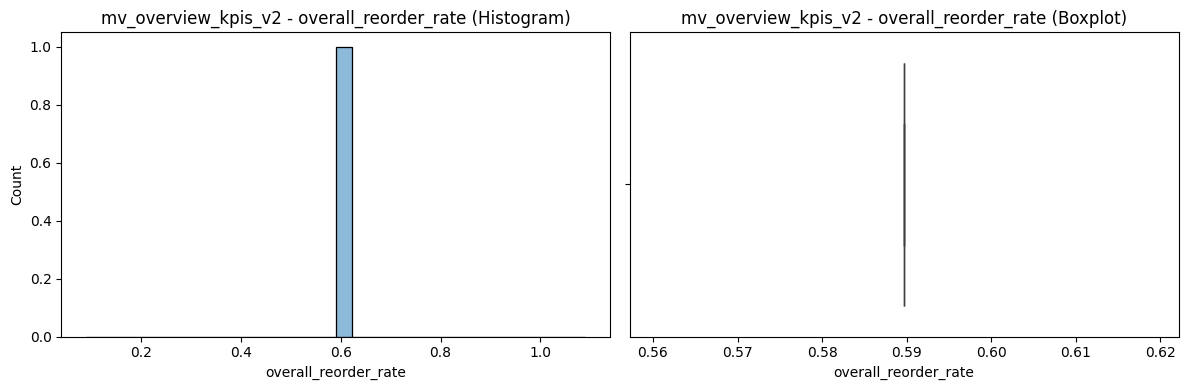

C:\Users\geeth\AppData\Local\Temp\ipykernel_15776\444686726.py:70: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  exists_df = pd.read_sql_query(exists_q, conn, params=[SCHEMA_NAME, mv_name])
C:\Users\geeth\AppData\Local\Temp\ipykernel_15776\444686726.py:81: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(full_q.as_string(conn), conn)



===== DISTRIBUTION ANALYSIS: public.mv_product_performance_v2 =====
Shape: (49677, 3)
Numeric columns selected for analysis: ['total_orders']
Numeric distribution summary:


,count,mean,std,min,25%,50%,75%,max,iqr,cv_pct,skew
total_orders,"49,677.0000",652.9076,"4,792.1144",1.0000,17.0000,60.0000,260.0000,"472,565.0000",243.0000,733.9652,44.8801


Outlier analysis (IQR + Z-score):


,table_name,column_name,count,mean,std,q1_25pct,median_50pct,q3_75pct,iqr,iqr_lower,iqr_upper,iqr_outlier_count,iqr_outlier_pct,z_outlier_count,z_outlier_pct,skew
0,mv_product_performance_v2,total_orders,49677,652.9076,"4,792.1144",17.0000,60.0000,260.0000,243.0000,-347.5000,624.5000,7117,14.3300,274,0.5500,44.8801


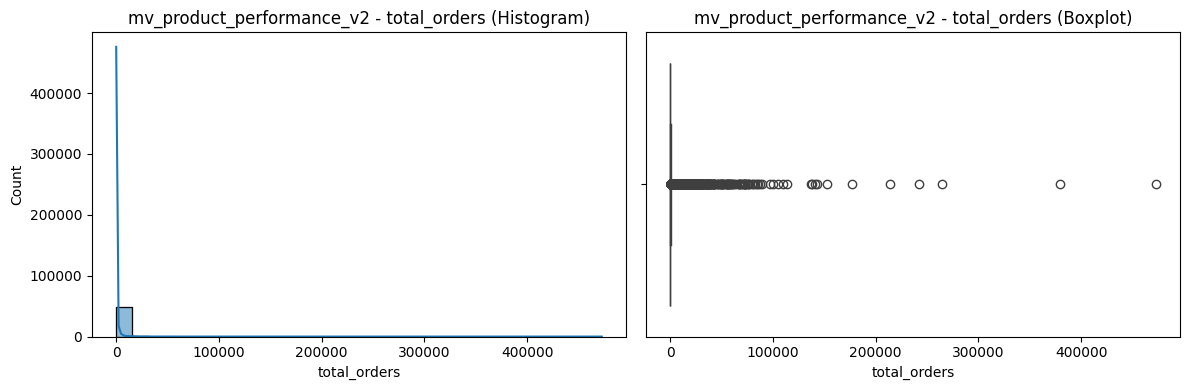


===== DISTRIBUTION ANALYSIS: public.mv_reorder_department_v2 =====
Shape: (21, 5)
Numeric columns selected for analysis: ['total_orders', 'reorder_count', 'reorder_rate']
Numeric distribution summary:


C:\Users\geeth\AppData\Local\Temp\ipykernel_15776\444686726.py:70: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  exists_df = pd.read_sql_query(exists_q, conn, params=[SCHEMA_NAME, mv_name])
C:\Users\geeth\AppData\Local\Temp\ipykernel_15776\444686726.py:81: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(full_q.as_string(conn), conn)


,count,mean,std,min,25%,50%,75%,max,iqr,cv_pct,skew
total_orders,21.0000,"1,544,499.4762","2,231,519.2502","34,573.0000","269,253.0000","738,666.0000","1,875,577.0000","9,479,291.0000","1,606,324.0000",144.4817,2.6802
reorder_count,21.0000,"910,787.4286","1,471,159.4360","14,806.0000","99,416.0000","399,581.0000","739,188.0000","6,160,710.0000","639,772.0000",161.5261,2.7852
reorder_rate,21.0000,0.5211,0.1098,0.3211,0.4080,0.5677,0.6013,0.6700,0.1933,21.0802,-0.4755


Outlier analysis (IQR + Z-score):


,table_name,column_name,count,mean,std,q1_25pct,median_50pct,q3_75pct,iqr,iqr_lower,iqr_upper,iqr_outlier_count,iqr_outlier_pct,z_outlier_count,z_outlier_pct,skew
0,mv_reorder_department_v2,total_orders,21,"1,544,499.4762","2,231,519.2502","269,253.0000","738,666.0000","1,875,577.0000","1,606,324.0000","-2,140,233.0000","4,285,063.0000",2,9.5200,1,4.7600,2.6802
1,mv_reorder_department_v2,reorder_count,21,"910,787.4286","1,471,159.4360","99,416.0000","399,581.0000","739,188.0000","639,772.0000","-860,242.0000","1,698,846.0000",3,14.2900,1,4.7600,2.7852
2,mv_reorder_department_v2,reorder_rate,21,0.5211,0.1098,0.4080,0.5677,0.6013,0.1933,0.1181,0.8912,0,0.0000,0,0.0000,-0.4755


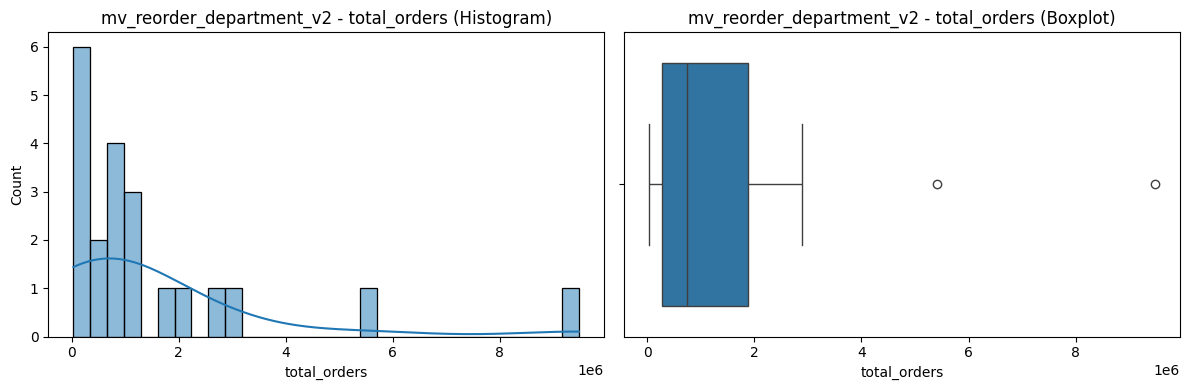

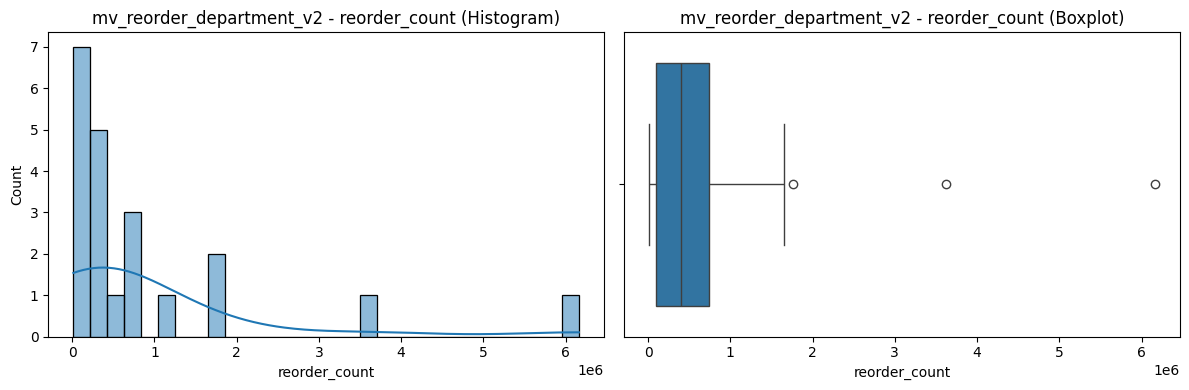

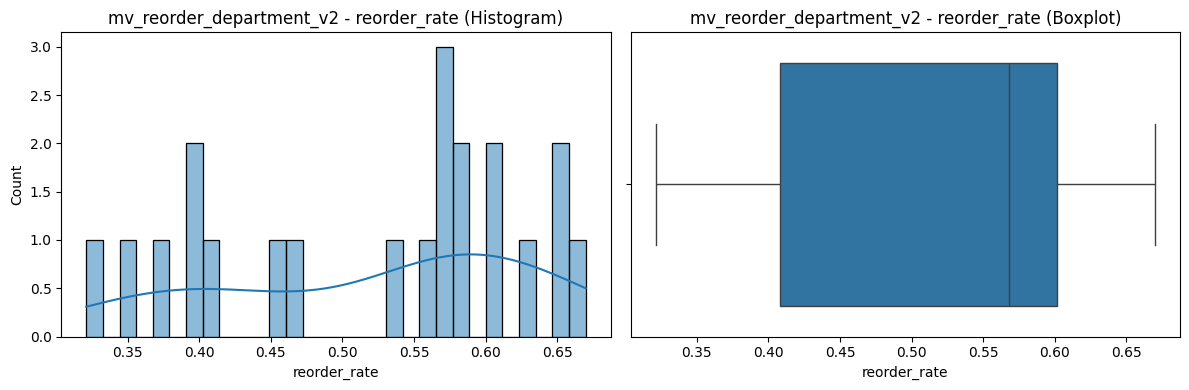

C:\Users\geeth\AppData\Local\Temp\ipykernel_15776\444686726.py:70: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  exists_df = pd.read_sql_query(exists_q, conn, params=[SCHEMA_NAME, mv_name])
C:\Users\geeth\AppData\Local\Temp\ipykernel_15776\444686726.py:81: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(full_q.as_string(conn), conn)



===== DISTRIBUTION ANALYSIS: public.mv_reorder_product_v2 =====
Shape: (49677, 5)
Numeric columns selected for analysis: ['total_orders', 'reorder_count', 'reorder_rate']
Numeric distribution summary:


,count,mean,std,min,25%,50%,75%,max,iqr,cv_pct,skew
total_orders,"49,677.0000",652.9076,"4,792.1144",1.0000,17.0000,60.0000,260.0000,"472,565.0000",243.0000,733.9652,44.8801
reorder_count,"49,677.0000",385.0179,"3,601.7136",0.0000,4.0000,22.0000,115.0000,"398,609.0000",111.0000,935.4665,56.1862
reorder_rate,"49,677.0000",0.3665,0.2081,0.0000,0.2081,0.3766,0.5293,0.9412,0.3212,56.7874,-0.1098


Outlier analysis (IQR + Z-score):


,table_name,column_name,count,mean,std,q1_25pct,median_50pct,q3_75pct,iqr,iqr_lower,iqr_upper,iqr_outlier_count,iqr_outlier_pct,z_outlier_count,z_outlier_pct,skew
0,mv_reorder_product_v2,total_orders,49677,652.9076,"4,792.1144",17.0000,60.0000,260.0000,243.0000,-347.5000,624.5000,7117,14.3300,274,0.5500,44.8801
1,mv_reorder_product_v2,reorder_count,49677,385.0179,"3,601.7136",4.0000,22.0000,115.0000,111.0000,-162.5000,281.5000,7471,15.0400,225,0.4500,56.1862
2,mv_reorder_product_v2,reorder_rate,49677,0.3665,0.2081,0.2081,0.3766,0.5293,0.3212,-0.2737,1.0111,0,0.0000,0,0.0000,-0.1098


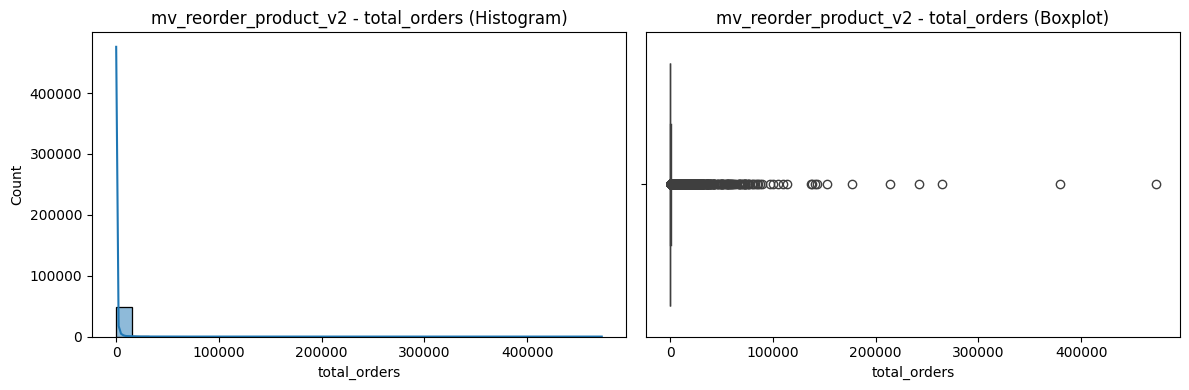

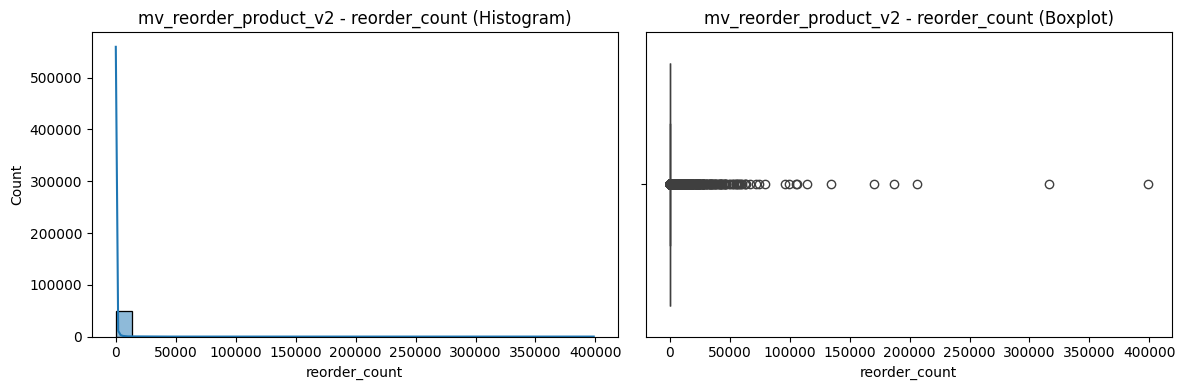

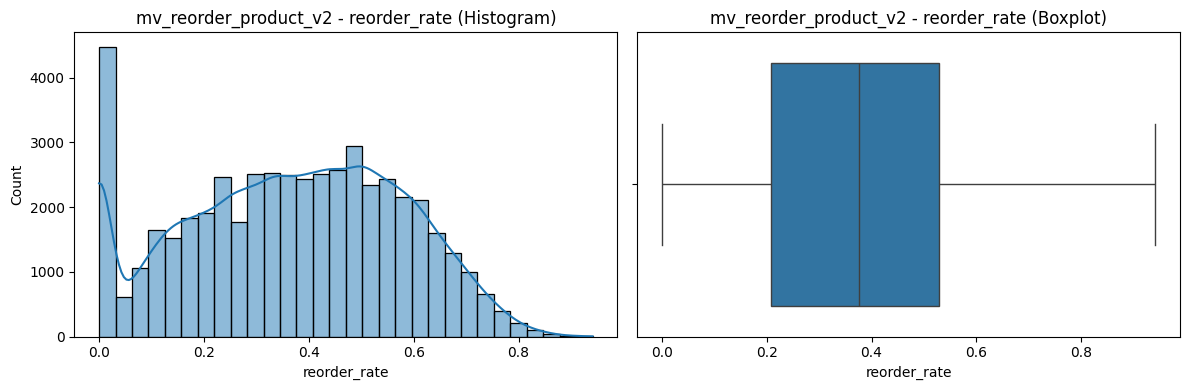


===== DISTRIBUTION ANALYSIS: public.mv_reorder_time_v2 =====
Shape: (24, 4)
Numeric columns selected for analysis: ['order_hour_of_day', 'total_orders', 'reorder_count', 'reorder_rate']
Numeric distribution summary:


C:\Users\geeth\AppData\Local\Temp\ipykernel_15776\444686726.py:70: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  exists_df = pd.read_sql_query(exists_q, conn, params=[SCHEMA_NAME, mv_name])
C:\Users\geeth\AppData\Local\Temp\ipykernel_15776\444686726.py:81: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(full_q.as_string(conn), conn)


,count,mean,std,min,25%,50%,75%,max,iqr,cv_pct,skew
order_hour_of_day,24.0000,11.5000,7.0711,0.0000,5.7500,11.5000,17.2500,23.0000,11.5000,61.4875,0.0000
total_orders,24.0000,"1,351,437.0417","1,079,358.3778","51,321.0000","272,833.2500","1,118,219.5000","2,558,305.2500","2,764,426.0000","2,285,472.0000",79.8675,0.1273
reorder_count,24.0000,"796,939.0000","634,489.7199","28,714.0000","169,771.2500","649,006.0000","1,519,160.5000","1,659,507.0000","1,349,389.2500",79.6158,0.1168
reorder_rate,24.0000,0.5873,0.0244,0.5545,0.5740,0.5803,0.5931,0.6445,0.0191,4.1545,1.0761


Outlier analysis (IQR + Z-score):


,table_name,column_name,count,mean,std,q1_25pct,median_50pct,q3_75pct,iqr,iqr_lower,iqr_upper,iqr_outlier_count,iqr_outlier_pct,z_outlier_count,z_outlier_pct,skew
0,mv_reorder_time_v2,order_hour_of_day,24,11.5000,7.0711,5.7500,11.5000,17.2500,11.5000,-11.5000,34.5000,0,0.0000,0,0.0000,0.0000
1,mv_reorder_time_v2,total_orders,24,"1,351,437.0417","1,079,358.3778","272,833.2500","1,118,219.5000","2,558,305.2500","2,285,472.0000","-3,155,374.7500","5,986,513.2500",0,0.0000,0,0.0000,0.1273
2,mv_reorder_time_v2,reorder_count,24,"796,939.0000","634,489.7199","169,771.2500","649,006.0000","1,519,160.5000","1,349,389.2500","-1,854,312.6250","3,543,244.3750",0,0.0000,0,0.0000,0.1168
3,mv_reorder_time_v2,reorder_rate,24,0.5873,0.0244,0.5740,0.5803,0.5931,0.0191,0.5454,0.6217,3,12.5000,0,0.0000,1.0761


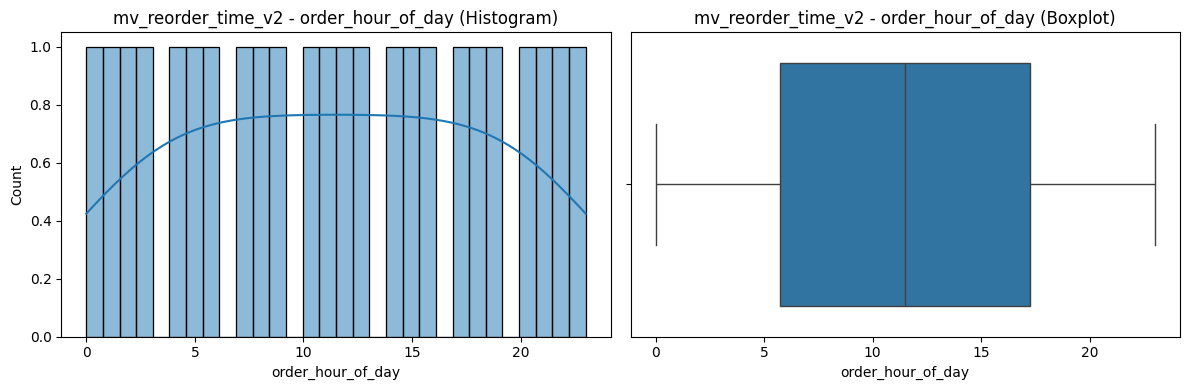

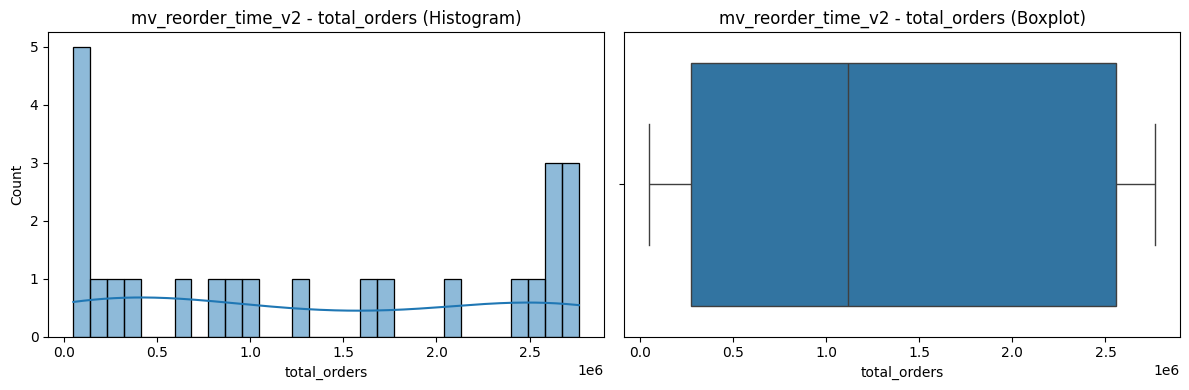

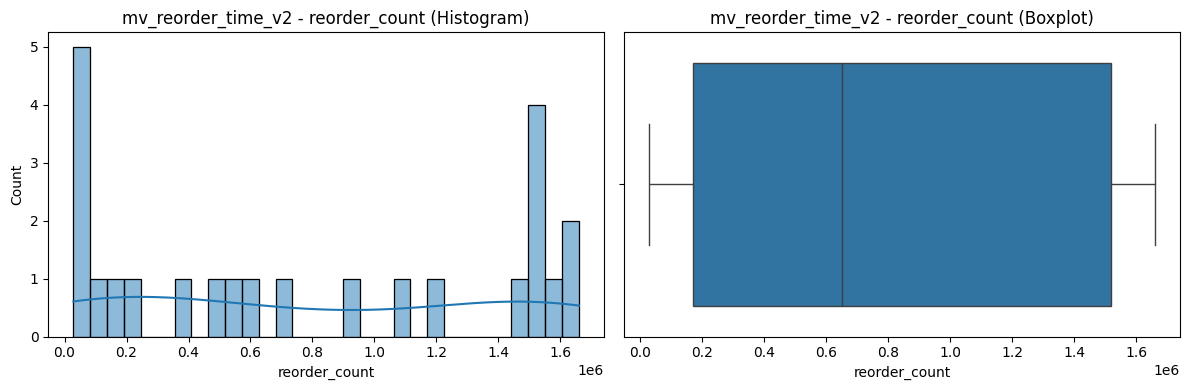

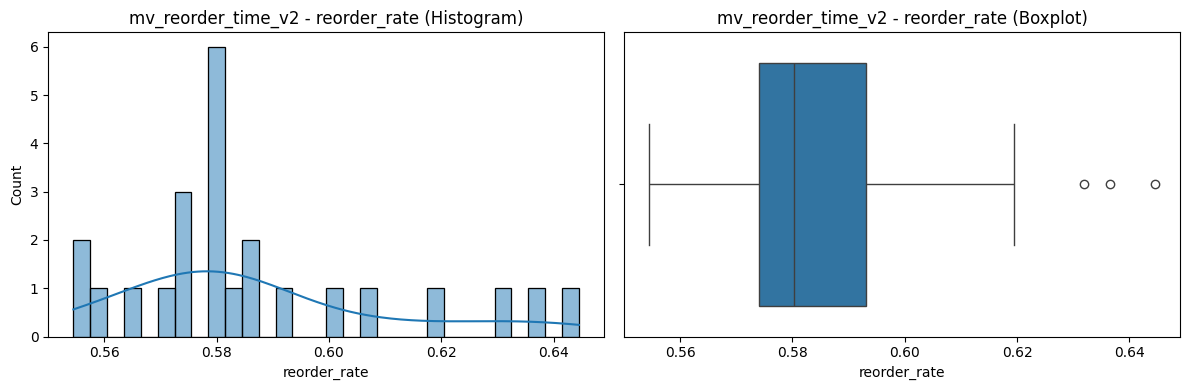


===== OVERALL DISTRIBUTION HEALTH SUMMARY =====


,table_name,rows,numeric_cols_analyzed,has_iqr_outliers,has_high_skew_abs_gt_1,avg_iqr_outlier_pct,avg_z_outlier_pct
0,mv_basket_analysis_v2,3214874,1,True,True,3.2700,1.5000
1,mv_department_performance_v2,21,1,True,True,9.5200,4.7600
2,mv_orders_time_v2,24,2,False,False,0.0000,0.0000
3,mv_overview_kpis_v2,1,4,False,False,0.0000,0.0000
4,mv_product_performance_v2,49677,1,True,True,14.3300,0.5500
5,mv_reorder_department_v2,21,3,True,True,7.9400,3.1700
6,mv_reorder_product_v2,49677,3,True,True,9.7900,0.3300
7,mv_reorder_time_v2,24,4,True,True,3.1200,0.0000


In [2]:
import math
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from psycopg2 import sql

# Fallback so this cell can run even if the connection helper cell wasn't executed first.
if "get_connection" not in globals():
    def get_connection():
        import psycopg2

        return psycopg2.connect(
            dbname="Instacart_Dw",
            user="postgres",
            password="root123"
        )

# ---------------------------------------------
# Advanced Distribution Analysis Configuration
# ---------------------------------------------
SCHEMA_NAME = "public"
MAX_NUMERIC_COLUMNS_PER_TABLE = 4    # keep visuals readable
PLOT_SAMPLE_SIZE = 100000            # downsample for fast plotting
Z_THRESHOLD = 3.0                    # |z| > 3 considered strong outlier
SHOW_PLOTS = True                    # set False if you only want summary tables

# Skip technical ID-like columns that are not useful for distribution profiling
EXCLUDED_NUMERIC_COLUMNS = {"product_id", "department_id", "order_id"}

# Optional: prioritize important business metrics if present
IMPORTANT_NUMERIC_COLUMNS_PRIORITY = [
    "add_to_cart_order",
    "reordered",
    "days_since_prior_order",
    "order_dow",
    "order_hour_of_day",
    "order_number",
    "user_total_orders",
    "product_orders",
    "product_reorders",
    "department_orders",
    "department_reorders",
]

# Optional: avoid scientific notation in output tables
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

# 1) Get materialized views from src/queries.py
queries_file = Path("../src/queries.py")
queries_text = queries_file.read_text(encoding="utf-8")
materialized_views = sorted(set(re.findall(r"\b(mv_[a-zA-Z0-9_]+)\b", queries_text)))

print("Materialized views found in src/queries.py:")
print(materialized_views)

conn = get_connection()
overall_distribution_rows = []

for mv_name in materialized_views:
    # Validate MV exists
    exists_q = """
    SELECT 1
    FROM pg_matviews
    WHERE schemaname = %s AND matviewname = %s;
    """
    exists_df = pd.read_sql_query(exists_q, conn, params=[SCHEMA_NAME, mv_name])

    if exists_df.empty:
        print(f"\nSkipped (not found as materialized view): {SCHEMA_NAME}.{mv_name}")
        continue

    # Load full table for accurate stats
    full_q = sql.SQL("SELECT * FROM {}.{};").format(
        sql.Identifier(SCHEMA_NAME),
        sql.Identifier(mv_name),
    )
    df = pd.read_sql_query(full_q.as_string(conn), conn)

    print(f"\n===== DISTRIBUTION ANALYSIS: {SCHEMA_NAME}.{mv_name} =====")
    print("Shape:", df.shape)

    if df.empty:
        print("No data in this materialized view.")
        continue

    # 2) Identify numeric columns and exclude non-business ID columns
    numeric_cols_all = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols_filtered = [
        c for c in numeric_cols_all
        if c.lower() not in EXCLUDED_NUMERIC_COLUMNS
    ]

    # Prioritize important business columns first (if they exist in this table)
    important_present = [
        c for c in IMPORTANT_NUMERIC_COLUMNS_PRIORITY
        if c in numeric_cols_filtered
    ]
    remaining_cols = [c for c in numeric_cols_filtered if c not in important_present]
    numeric_cols_ranked = important_present + remaining_cols
    numeric_cols = numeric_cols_ranked[:MAX_NUMERIC_COLUMNS_PER_TABLE]

    if not numeric_cols:
        print("No eligible important numeric columns found after exclusions. Skipping distribution checks.")
        continue

    print("Numeric columns selected for analysis:", numeric_cols)

    # 3) Quick summary for selected numeric columns
    summary_df = df[numeric_cols].describe(percentiles=[0.25, 0.5, 0.75]).transpose()
    summary_df["iqr"] = summary_df["75%"] - summary_df["25%"]
    summary_df["cv_pct"] = np.where(summary_df["mean"] != 0, (summary_df["std"] / summary_df["mean"]) * 100, np.nan)
    summary_df["skew"] = df[numeric_cols].skew(numeric_only=True)

    print("Numeric distribution summary:")
    display(summary_df)

    # 4) Outlier checks: IQR and Z-score
    outlier_rows = []
    for col in numeric_cols:
        series = df[col].dropna()
        n = len(series)

        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        iqr_lower = q1 - 1.5 * iqr
        iqr_upper = q3 + 1.5 * iqr
        iqr_outliers = int(((series < iqr_lower) | (series > iqr_upper)).sum())

        mean_val = float(series.mean())
        std_val = float(series.std())
        if std_val == 0 or math.isnan(std_val):
            z_outliers = 0
        else:
            z_scores = (series - mean_val) / std_val
            z_outliers = int((z_scores.abs() > Z_THRESHOLD).sum())

        outlier_rows.append(
            {
                "table_name": mv_name,
                "column_name": col,
                "count": n,
                "mean": mean_val,
                "std": std_val,
                "q1_25pct": q1,
                "median_50pct": series.median(),
                "q3_75pct": q3,
                "iqr": iqr,
                "iqr_lower": iqr_lower,
                "iqr_upper": iqr_upper,
                "iqr_outlier_count": iqr_outliers,
                "iqr_outlier_pct": round((iqr_outliers / n) * 100, 2) if n else 0.0,
                "z_outlier_count": z_outliers,
                "z_outlier_pct": round((z_outliers / n) * 100, 2) if n else 0.0,
                "skew": float(series.skew()) if n > 2 else np.nan,
            }
        )

    outlier_df = pd.DataFrame(outlier_rows)
    print("Outlier analysis (IQR + Z-score):")
    display(outlier_df)

    # 5) Visual distribution analysis
    if SHOW_PLOTS:
        plot_df = df[numeric_cols].copy()
        if len(plot_df) > PLOT_SAMPLE_SIZE:
            plot_df = plot_df.sample(PLOT_SAMPLE_SIZE, random_state=42)

        for col in numeric_cols:
            fig, axes = plt.subplots(1, 2, figsize=(12, 4))

            sns.histplot(plot_df[col].dropna(), kde=True, ax=axes[0], bins=30)
            axes[0].set_title(f"{mv_name} - {col} (Histogram)")
            axes[0].set_xlabel(col)

            sns.boxplot(x=plot_df[col], ax=axes[1])
            axes[1].set_title(f"{mv_name} - {col} (Boxplot)")
            axes[1].set_xlabel(col)

            plt.tight_layout()
            plt.show()

    # 6) Table-level distribution health summary
    table_has_iqr_outliers = bool((outlier_df["iqr_outlier_count"] > 0).any())
    table_has_high_skew = bool((outlier_df["skew"].abs() > 1).fillna(False).any())

    overall_distribution_rows.append(
        {
            "table_name": mv_name,
            "rows": len(df),
            "numeric_cols_analyzed": len(numeric_cols),
            "has_iqr_outliers": table_has_iqr_outliers,
            "has_high_skew_abs_gt_1": table_has_high_skew,
            "avg_iqr_outlier_pct": round(outlier_df["iqr_outlier_pct"].mean(), 2),
            "avg_z_outlier_pct": round(outlier_df["z_outlier_pct"].mean(), 2),
        }
    )

# 7) Overall summary across all tables
if overall_distribution_rows:
    overall_distribution_df = pd.DataFrame(overall_distribution_rows)
    print("\n===== OVERALL DISTRIBUTION HEALTH SUMMARY =====")
    display(overall_distribution_df)

conn.close()

In [3]:
import math
import pandas as pd
import numpy as np
from psycopg2 import sql

# Focused outlier detection: only key performance tables
TARGET_TABLES = [
    "mv_product_performance_v2",
    "mv_department_performance_v2",
    "mv_basket_analysis_v2",
]

# Exclude technical IDs and low-value columns for business outlier review
EXCLUDED_COLUMNS = {
    "product_id",
    "department_id",
    "order_id",
    "user_id",
    "aisle_id",
    "category_id",
}

# Optional: highlight these important metrics first when present
PRIORITY_METRICS = [
    "total_orders",
    "reordered_orders",
    "reorder_rate",
    "avg_add_to_cart_order",
    "avg_days_since_prior_order",
    "distinct_users",
    "avg_basket_size",
]

IQR_MULTIPLIER = 1.5
Z_THRESHOLD = 3.0
SCHEMA_NAME = "public"

if "get_connection" not in globals():
    def get_connection():
        import psycopg2

        return psycopg2.connect(
            dbname="Instacart_Dw",
            user="postgres",
            password="root123"
        )

conn = get_connection()
table_summaries = []
column_summaries = []

for table_name in TARGET_TABLES:
    exists_q = """
    SELECT 1
    FROM pg_matviews
    WHERE schemaname = %s AND matviewname = %s;
    """
    exists_df = pd.read_sql_query(exists_q, conn, params=[SCHEMA_NAME, table_name])

    if exists_df.empty:
        print(f"Skipped (materialized view not found): {SCHEMA_NAME}.{table_name}")
        continue

    full_q = sql.SQL("SELECT * FROM {}.{};").format(
        sql.Identifier(SCHEMA_NAME),
        sql.Identifier(table_name),
    )
    df = pd.read_sql_query(full_q.as_string(conn), conn)

    if df.empty:
        print(f"Skipped (no rows): {SCHEMA_NAME}.{table_name}")
        continue

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c.lower() not in EXCLUDED_COLUMNS]

    # Rank metrics: important ones first, then remaining numeric columns
    priority_present = [c for c in PRIORITY_METRICS if c in numeric_cols]
    remaining = [c for c in numeric_cols if c not in priority_present]
    ranked_cols = priority_present + remaining

    if not ranked_cols:
        print(f"Skipped (no eligible numeric columns): {SCHEMA_NAME}.{table_name}")
        continue

    print(f"\n===== OUTLIER CHECK: {SCHEMA_NAME}.{table_name} =====")
    print("Columns analyzed:", ranked_cols)

    table_outlier_hits = 0
    for col in ranked_cols:
        s = df[col].dropna()
        n = len(s)

        if n == 0:
            continue

        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - IQR_MULTIPLIER * iqr
        upper = q3 + IQR_MULTIPLIER * iqr
        iqr_outlier_count = int(((s < lower) | (s > upper)).sum())

        std_val = float(s.std())
        mean_val = float(s.mean())
        if std_val == 0 or math.isnan(std_val):
            z_outlier_count = 0
        else:
            z_scores = (s - mean_val) / std_val
            z_outlier_count = int((z_scores.abs() > Z_THRESHOLD).sum())

        column_summaries.append(
            {
                "table_name": table_name,
                "column_name": col,
                "row_count": n,
                "iqr_outlier_count": iqr_outlier_count,
                "iqr_outlier_pct": round((iqr_outlier_count / n) * 100, 2),
                "z_outlier_count": z_outlier_count,
                "z_outlier_pct": round((z_outlier_count / n) * 100, 2),
                "mean": round(mean_val, 4),
                "std": round(std_val, 4),
            }
        )

        if iqr_outlier_count > 0 or z_outlier_count > 0:
            table_outlier_hits += 1

    table_summaries.append(
        {
            "table_name": table_name,
            "rows": len(df),
            "numeric_cols_analyzed": len(ranked_cols),
            "columns_with_any_outlier": table_outlier_hits,
            "has_outliers": table_outlier_hits > 0,
        }
    )

conn.close()

if table_summaries:
    table_summary_df = pd.DataFrame(table_summaries)
    print("\n===== TABLE-LEVEL OUTLIER SUMMARY =====")
    display(table_summary_df)

if column_summaries:
    column_summary_df = pd.DataFrame(column_summaries)
    column_summary_df = column_summary_df.sort_values(
        ["iqr_outlier_pct", "z_outlier_pct"], ascending=[False, False]
    )
    print("\n===== COLUMN-LEVEL OUTLIER DETAILS =====")
    display(column_summary_df)

C:\Users\geeth\AppData\Local\Temp\ipykernel_15776\1162094680.py:58: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  exists_df = pd.read_sql_query(exists_q, conn, params=[SCHEMA_NAME, table_name])
C:\Users\geeth\AppData\Local\Temp\ipykernel_15776\1162094680.py:68: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(full_q.as_string(conn), conn)



===== OUTLIER CHECK: public.mv_product_performance_v2 =====
Columns analyzed: ['total_orders']

===== OUTLIER CHECK: public.mv_department_performance_v2 =====
Columns analyzed: ['total_orders']


C:\Users\geeth\AppData\Local\Temp\ipykernel_15776\1162094680.py:58: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  exists_df = pd.read_sql_query(exists_q, conn, params=[SCHEMA_NAME, table_name])
C:\Users\geeth\AppData\Local\Temp\ipykernel_15776\1162094680.py:68: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(full_q.as_string(conn), conn)
C:\Users\geeth\AppData\Local\Temp\ipykernel_15776\1162094680.py:58: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  exists_df = pd.read_sql_query(exists_q, conn, params=[


===== OUTLIER CHECK: public.mv_basket_analysis_v2 =====
Columns analyzed: ['basket_size']

===== TABLE-LEVEL OUTLIER SUMMARY =====


,table_name,rows,numeric_cols_analyzed,columns_with_any_outlier,has_outliers
0,mv_product_performance_v2,49677,1,1,True
1,mv_department_performance_v2,21,1,1,True
2,mv_basket_analysis_v2,3214874,1,1,True



===== COLUMN-LEVEL OUTLIER DETAILS =====


,table_name,column_name,row_count,iqr_outlier_count,iqr_outlier_pct,z_outlier_count,z_outlier_pct,mean,std
0,mv_product_performance_v2,total_orders,49677,7117,14.3300,274,0.5500,652.9076,"4,792.1144"
1,mv_department_performance_v2,total_orders,21,2,9.5200,1,4.7600,"1,544,499.4762","2,231,519.2502"
2,mv_basket_analysis_v2,basket_size,3214874,105058,3.2700,48066,1.5000,10.0889,7.5254


In [4]:
import numpy as np
import pandas as pd
from psycopg2 import sql

# Data-quality checks for the 3 key performance tables + outlier handling guidance
TARGET_TABLES = [
    "mv_product_performance_v2",
    "mv_department_performance_v2",
    "mv_basket_analysis_v2",
]
SCHEMA_NAME = "public"

if "get_connection" not in globals():
    def get_connection():
        import psycopg2

        return psycopg2.connect(
            dbname="Instacart_Dw",
            user="postgres",
            password="root123"
        )

def detect_quality_issues(df: pd.DataFrame, table_name: str):
    issues = []

    # 1) Exact duplicate rows
    dup_rows = int(df.duplicated().sum())
    if dup_rows > 0:
        issues.append({
            "table_name": table_name,
            "check_type": "duplicate_rows",
            "column_name": "__row__",
            "issue_count": dup_rows,
            "issue_pct": round((dup_rows / len(df)) * 100, 2) if len(df) else 0.0,
            "severity": "high" if dup_rows > 0 else "low",
            "note": "Exact duplicate rows found.",
        })

    # 2) Negative value checks for count/quantity-like metrics
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    for col in numeric_cols:
        col_l = col.lower()
        check_negative = any(
            k in col_l for k in ["count", "qty", "quantity", "orders", "total", "basket_size", "days", "hour", "dow", "rate", "pct", "percent", "add_to_cart"]
        )
        if check_negative:
            neg_count = int((df[col] < 0).sum())
            if neg_count > 0:
                issues.append({
                    "table_name": table_name,
                    "check_type": "negative_values",
                    "column_name": col,
                    "issue_count": neg_count,
                    "issue_pct": round((neg_count / len(df)) * 100, 2),
                    "severity": "high",
                    "note": "Negative values in a non-negative business metric.",
                })

    # 3) Impossible range checks
    for col in numeric_cols:
        col_l = col.lower()
        s = df[col]

        if "reorder_rate" in col_l or col_l.endswith("_rate"):
            bad = int(((s < 0) | (s > 1)).sum())
            if bad > 0:
                issues.append({
                    "table_name": table_name,
                    "check_type": "invalid_range",
                    "column_name": col,
                    "issue_count": bad,
                    "issue_pct": round((bad / len(df)) * 100, 2),
                    "severity": "high",
                    "note": "Rate should be between 0 and 1.",
                })

        if "pct" in col_l or "percent" in col_l:
            bad = int(((s < 0) | (s > 100)).sum())
            if bad > 0:
                issues.append({
                    "table_name": table_name,
                    "check_type": "invalid_range",
                    "column_name": col,
                    "issue_count": bad,
                    "issue_pct": round((bad / len(df)) * 100, 2),
                    "severity": "high",
                    "note": "Percentage should be between 0 and 100.",
                })

        if "hour" in col_l:
            bad = int(((s < 0) | (s > 23)).sum())
            if bad > 0:
                issues.append({
                    "table_name": table_name,
                    "check_type": "invalid_range",
                    "column_name": col,
                    "issue_count": bad,
                    "issue_pct": round((bad / len(df)) * 100, 2),
                    "severity": "medium",
                    "note": "Hour should be in 0-23.",
                })

        if col_l.endswith("_dow") or col_l == "order_dow" or "day_of_week" in col_l:
            bad = int(((s < 0) | (s > 6)).sum())
            if bad > 0:
                issues.append({
                    "table_name": table_name,
                    "check_type": "invalid_range",
                    "column_name": col,
                    "issue_count": bad,
                    "issue_pct": round((bad / len(df)) * 100, 2),
                    "severity": "medium",
                    "note": "Day-of-week should be in 0-6.",
                })

        if "add_to_cart_order" in col_l:
            bad = int((s < 1).sum())
            if bad > 0:
                issues.append({
                    "table_name": table_name,
                    "check_type": "invalid_range",
                    "column_name": col,
                    "issue_count": bad,
                    "issue_pct": round((bad / len(df)) * 100, 2),
                    "severity": "medium",
                    "note": "Add-to-cart order should be >= 1.",
                })

    # 4) Suspected bad joins: ID exists but description/name is null
    id_cols = [c for c in df.columns if c.lower().endswith("_id")]

    # Try matching product_id -> product_name, department_id -> department, etc.
    for id_col in id_cols:
        base = id_col[:-3]  # remove _id
        candidate_names = [f"{base}_name", base]
        matched_name_col = next((n for n in candidate_names if n in df.columns), None)
        if matched_name_col is None:
            continue

        bad_join_count = int((df[id_col].notna() & df[matched_name_col].isna()).sum())
        if bad_join_count > 0:
            issues.append({
                "table_name": table_name,
                "check_type": "suspected_bad_join",
                "column_name": f"{id_col}->{matched_name_col}",
                "issue_count": bad_join_count,
                "issue_pct": round((bad_join_count / len(df)) * 100, 2),
                "severity": "high",
                "note": "ID present but mapped name missing (possible join/key mismatch).",
            })

    return issues

def recommend_outlier_action(summary_df: pd.DataFrame, quality_df: pd.DataFrame):
    recs = []
    if summary_df.empty:
        return pd.DataFrame()

    quality_issue_columns = set()
    if not quality_df.empty:
        quality_issue_columns = set(
            quality_df.loc[quality_df["column_name"].str.contains("->", na=False) == False, "column_name"].astype(str).tolist()
        )

    for _, row in summary_df.iterrows():
        col = row["column_name"]
        iqr_pct = float(row.get("iqr_outlier_pct", 0.0))
        z_pct = float(row.get("z_outlier_pct", 0.0))
        mean_val = float(row.get("mean", np.nan))
        std_val = float(row.get("std", np.nan))

        if col in quality_issue_columns:
            action = "Investigate and fix source data first; do not model this column yet."
            reason = "Detected data-quality issues in this column."
        elif std_val == 0 or np.isnan(std_val):
            action = "Keep as-is; no outlier treatment needed."
            reason = "Column is almost constant (no variance)."
        elif max(iqr_pct, z_pct) >= 10:
            action = "Keep raw + create capped version (1st/99th percentile) for dashboards/models."
            reason = "High outlier share; capping improves robustness while preserving original signal."
        elif max(iqr_pct, z_pct) >= 2:
            action = "Keep raw + add outlier flag column; use median/IQR-based reporting."
            reason = "Moderate outliers; likely real business variation."
        else:
            action = "Keep as-is; only monitor."
            reason = "Low outlier share."

        recs.append({
            "table_name": row["table_name"],
            "column_name": col,
            "iqr_outlier_pct": round(iqr_pct, 2),
            "z_outlier_pct": round(z_pct, 2),
            "recommended_action": action,
            "reason": reason,
            "mean": round(mean_val, 4) if not np.isnan(mean_val) else np.nan,
            "std": round(std_val, 4) if not np.isnan(std_val) else np.nan,
        })

    return pd.DataFrame(recs)

conn = get_connection()
quality_issues_all = []
outlier_column_all = []

for table_name in TARGET_TABLES:
    exists_q = """
    SELECT 1
    FROM pg_matviews
    WHERE schemaname = %s AND matviewname = %s;
    """
    exists_df = pd.read_sql_query(exists_q, conn, params=[SCHEMA_NAME, table_name])
    if exists_df.empty:
        print(f"Skipped (materialized view not found): {SCHEMA_NAME}.{table_name}")
        continue

    full_q = sql.SQL("SELECT * FROM {}.{};").format(
        sql.Identifier(SCHEMA_NAME),
        sql.Identifier(table_name),
    )
    df = pd.read_sql_query(full_q.as_string(conn), conn)
    if df.empty:
        print(f"Skipped (no rows): {SCHEMA_NAME}.{table_name}")
        continue

    # Quality checks
    quality_issues_all.extend(detect_quality_issues(df, table_name))

    # Column-level outlier stats for recommendation engine
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    excluded = {"product_id", "department_id", "order_id", "user_id", "aisle_id", "category_id"}
    numeric_cols = [c for c in numeric_cols if c.lower() not in excluded]

    for col in numeric_cols:
        s = df[col].dropna()
        if len(s) == 0:
            continue

        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        iqr_out = int(((s < lower) | (s > upper)).sum())

        std_val = float(s.std())
        mean_val = float(s.mean())
        if std_val == 0 or np.isnan(std_val):
            z_out = 0
        else:
            z_out = int((((s - mean_val) / std_val).abs() > 3.0).sum())

        outlier_column_all.append({
            "table_name": table_name,
            "column_name": col,
            "iqr_outlier_pct": round((iqr_out / len(s)) * 100, 2),
            "z_outlier_pct": round((z_out / len(s)) * 100, 2),
            "mean": mean_val,
            "std": std_val,
        })

conn.close()

quality_issues_df = pd.DataFrame(quality_issues_all)
outlier_summary_df = pd.DataFrame(outlier_column_all)
recommendations_df = recommend_outlier_action(outlier_summary_df, quality_issues_df)

print("===== DATA QUALITY ISSUES =====")
if quality_issues_df.empty:
    print("No obvious quality issues found in the configured checks.")
else:
    display(quality_issues_df.sort_values(["severity", "issue_pct"], ascending=[True, False]))

print("\n===== OUTLIER HANDLING RECOMMENDATIONS =====")
if recommendations_df.empty:
    print("No recommendation output generated.")
else:
    display(recommendations_df.sort_values(["iqr_outlier_pct", "z_outlier_pct"], ascending=[False, False]))

C:\Users\geeth\AppData\Local\Temp\ipykernel_15776\2794738690.py:211: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  exists_df = pd.read_sql_query(exists_q, conn, params=[SCHEMA_NAME, table_name])
C:\Users\geeth\AppData\Local\Temp\ipykernel_15776\2794738690.py:220: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(full_q.as_string(conn), conn)
C:\Users\geeth\AppData\Local\Temp\ipykernel_15776\2794738690.py:211: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  exists_df = pd.read_sql_query(exists_q, conn, param

===== DATA QUALITY ISSUES =====
No obvious quality issues found in the configured checks.

===== OUTLIER HANDLING RECOMMENDATIONS =====


,table_name,column_name,iqr_outlier_pct,z_outlier_pct,recommended_action,reason,mean,std
0,mv_product_performance_v2,total_orders,14.3300,0.5500,Keep raw + create capped version (1st/99th per...,High outlier share; capping improves robustnes...,652.9076,"4,792.1144"
1,mv_department_performance_v2,total_orders,9.5200,4.7600,Keep raw + add outlier flag column; use median...,Moderate outliers; likely real business variat...,"1,544,499.4762","2,231,519.2502"
2,mv_basket_analysis_v2,basket_size,3.2700,1.5000,Keep raw + add outlier flag column; use median...,Moderate outliers; likely real business variat...,10.0889,7.5254


In [5]:
import pandas as pd
from psycopg2 import sql

# Apply recommended actions from Cell 6
TARGET_TABLES = [
    "mv_product_performance_v2",
    "mv_department_performance_v2",
    "mv_basket_analysis_v2",
]
SCHEMA_NAME = "public"

# Columns that should not be used for numeric outlier treatment
ID_EXCLUDED = {"product_id", "department_id", "order_id", "user_id", "aisle_id", "category_id"}

# Action thresholds (aligned with Cell 6 recommendation logic)
HIGH_OUTLIER_THRESHOLD_PCT = 10.0
MODERATE_OUTLIER_THRESHOLD_PCT = 2.0

if "get_connection" not in globals():
    def get_connection():
        import psycopg2

        return psycopg2.connect(
            dbname="Instacart_Dw",
            user="postgres",
            password="root123"
        )

if "recommendations_df" not in globals():
    raise RuntimeError(
        "recommendations_df not found. Run Cell 6 first to generate recommendations before applying actions."
    )

if "quality_issues_df" not in globals():
    quality_issues_df = pd.DataFrame()

def cap_series_percentiles(s: pd.Series, lower_q: float = 0.01, upper_q: float = 0.99):
    lo = s.quantile(lower_q)
    hi = s.quantile(upper_q)
    return s.clip(lower=lo, upper=hi), float(lo), float(hi)

# Track outputs so you can reuse them in later cells
applied_raw_tables = {}
applied_clean_tables = {}
applied_action_log_rows = []
applied_table_summary_rows = []

# Build a set of columns with data-quality issues (non-join mapping rows only)
quality_issue_cols = set()
if not quality_issues_df.empty:
    if "column_name" in quality_issues_df.columns:
        quality_issue_cols = set(
            quality_issues_df.loc[
                ~quality_issues_df["column_name"].astype(str).str.contains("->", na=False),
                "column_name",
            ].astype(str).tolist()
        )

conn = get_connection()

for table_name in TARGET_TABLES:
    exists_q = """
    SELECT 1
    FROM pg_matviews
    WHERE schemaname = %s AND matviewname = %s;
    """
    exists_df = pd.read_sql_query(exists_q, conn, params=[SCHEMA_NAME, table_name])
    if exists_df.empty:
        print(f"Skipped (materialized view not found): {SCHEMA_NAME}.{table_name}")
        continue

    full_q = sql.SQL("SELECT * FROM {}.{};").format(
        sql.Identifier(SCHEMA_NAME),
        sql.Identifier(table_name),
    )
    df_raw = pd.read_sql_query(full_q.as_string(conn), conn)
    if df_raw.empty:
        print(f"Skipped (no rows): {SCHEMA_NAME}.{table_name}")
        continue

    # 1) Remove exact duplicate rows
    before_rows = len(df_raw)
    df_clean = df_raw.drop_duplicates().copy()
    duplicates_removed = before_rows - len(df_clean)

    # Get recommendations for this table
    table_recs = recommendations_df[recommendations_df["table_name"] == table_name].copy()
    if table_recs.empty:
        print(f"No recommendations found for {table_name}; only duplicate removal applied.")

    cols_capped = 0
    cols_flagged = 0
    cols_skipped_quality = 0

    for _, rec in table_recs.iterrows():
        col = rec["column_name"]
        if col not in df_clean.columns:
            continue

        # Only apply numeric actions
        if not pd.api.types.is_numeric_dtype(df_clean[col]):
            continue

        # Skip ID-like columns
        if col.lower() in ID_EXCLUDED:
            continue

        iqr_pct = float(rec.get("iqr_outlier_pct", 0.0))
        z_pct = float(rec.get("z_outlier_pct", 0.0))
        max_outlier_pct = max(iqr_pct, z_pct)

        # If quality issue exists, do not transform; mark for source fix
        if col in quality_issue_cols:
            cols_skipped_quality += 1
            applied_action_log_rows.append({
                "table_name": table_name,
                "column_name": col,
                "action": "skip_transform_quality_issue",
                "details": "Column has quality issue; investigate source data before treatment.",
            })
            continue

        series = df_clean[col]
        non_null = series.dropna()
        if non_null.empty:
            continue

        # Always create an outlier flag when moderate/high outlier share
        if max_outlier_pct >= MODERATE_OUTLIER_THRESHOLD_PCT:
            q1 = non_null.quantile(0.25)
            q3 = non_null.quantile(0.75)
            iqr = q3 - q1
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr
            flag_col = f"{col}_is_outlier_iqr"
            df_clean[flag_col] = ((df_clean[col] < lower) | (df_clean[col] > upper)).astype("Int64")
            cols_flagged += 1

            applied_action_log_rows.append({
                "table_name": table_name,
                "column_name": col,
                "action": "add_outlier_flag",
                "details": f"Created {flag_col} using IQR bounds [{lower:.4f}, {upper:.4f}].",
            })

        # Create capped version for high outlier share
        if max_outlier_pct >= HIGH_OUTLIER_THRESHOLD_PCT:
            capped, lo, hi = cap_series_percentiles(df_clean[col], 0.01, 0.99)
            capped_col = f"{col}_capped_p01_p99"
            df_clean[capped_col] = capped
            cols_capped += 1

            applied_action_log_rows.append({
                "table_name": table_name,
                "column_name": col,
                "action": "create_capped_column",
                "details": f"Created {capped_col} with clipping bounds [{lo:.4f}, {hi:.4f}].",
            })

    applied_raw_tables[table_name] = df_raw
    applied_clean_tables[table_name] = df_clean

    applied_table_summary_rows.append({
        "table_name": table_name,
        "raw_rows": before_rows,
        "clean_rows": len(df_clean),
        "duplicates_removed": duplicates_removed,
        "columns_flagged": cols_flagged,
        "columns_capped": cols_capped,
        "columns_skipped_due_to_quality_issue": cols_skipped_quality,
    })

conn.close()

applied_actions_df = pd.DataFrame(applied_action_log_rows)
applied_table_summary_df = pd.DataFrame(applied_table_summary_rows)

print("===== APPLIED ACTION SUMMARY =====")
if applied_table_summary_df.empty:
    print("No actions applied.")
else:
    display(applied_table_summary_df)

print("\n===== APPLIED ACTION LOG =====")
if applied_actions_df.empty:
    print("No column-level actions were applied.")
else:
    display(applied_actions_df)

print("\nReusable outputs created:")
print("- applied_raw_tables[table_name]")
print("- applied_clean_tables[table_name]")
print("- applied_table_summary_df")
print("- applied_actions_df")

C:\Users\geeth\AppData\Local\Temp\ipykernel_15776\1009512061.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  exists_df = pd.read_sql_query(exists_q, conn, params=[SCHEMA_NAME, table_name])
C:\Users\geeth\AppData\Local\Temp\ipykernel_15776\1009512061.py:76: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_raw = pd.read_sql_query(full_q.as_string(conn), conn)
C:\Users\geeth\AppData\Local\Temp\ipykernel_15776\1009512061.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  exists_df = pd.read_sql_query(exists_q, conn, para

===== APPLIED ACTION SUMMARY =====


,table_name,raw_rows,clean_rows,duplicates_removed,columns_flagged,columns_capped,columns_skipped_due_to_quality_issue
0,mv_product_performance_v2,49677,49677,0,1,1,0
1,mv_department_performance_v2,21,21,0,1,0,0
2,mv_basket_analysis_v2,3214874,3214874,0,1,0,0



===== APPLIED ACTION LOG =====


,table_name,column_name,action,details
0,mv_product_performance_v2,total_orders,add_outlier_flag,Created total_orders_is_outlier_iqr using IQR ...
1,mv_product_performance_v2,total_orders,create_capped_column,Created total_orders_capped_p01_p99 with clipp...
2,mv_department_performance_v2,total_orders,add_outlier_flag,Created total_orders_is_outlier_iqr using IQR ...
3,mv_basket_analysis_v2,basket_size,add_outlier_flag,Created basket_size_is_outlier_iqr using IQR b...



Reusable outputs created:
- applied_raw_tables[table_name]
- applied_clean_tables[table_name]
- applied_table_summary_df
- applied_actions_df


In [6]:
# Compare raw vs cleaned tables after applying actions
if "applied_raw_tables" not in globals() or "applied_clean_tables" not in globals():
    raise RuntimeError("Run Cell 7 first so applied_raw_tables/applied_clean_tables are available.")

comparison_rows = []

for table_name in applied_raw_tables.keys():
    raw_df = applied_raw_tables[table_name]
    clean_df = applied_clean_tables[table_name]

    raw_cols = set(raw_df.columns)
    clean_cols = set(clean_df.columns)
    added_cols = sorted(list(clean_cols - raw_cols))
    removed_cols = sorted(list(raw_cols - clean_cols))

    comparison_rows.append({
        "table_name": table_name,
        "raw_rows": len(raw_df),
        "clean_rows": len(clean_df),
        "row_difference": len(clean_df) - len(raw_df),
        "raw_cols": len(raw_cols),
        "clean_cols": len(clean_cols),
        "new_columns_added": len(added_cols),
        "columns_removed": len(removed_cols),
        "sample_new_columns": ", ".join(added_cols[:6]) if added_cols else "None",
    })

comparison_df = pd.DataFrame(comparison_rows)
print("===== RAW VS CLEAN TABLE SHAPE COMPARISON =====")
display(comparison_df)

for table_name in applied_raw_tables.keys():
    raw_df = applied_raw_tables[table_name]
    clean_df = applied_clean_tables[table_name]

    added_cols = [c for c in clean_df.columns if c not in raw_df.columns]
    print(f"\n===== {table_name} =====")
    print(f"Rows: raw={len(raw_df)}, clean={len(clean_df)}")
    print(f"Added columns: {len(added_cols)}")
    if added_cols:
        print("Added column names:", added_cols)
        print("Preview with added columns:")
        display(clean_df[added_cols].head(5))
    else:
        print("No new columns were added for this table.")

===== RAW VS CLEAN TABLE SHAPE COMPARISON =====


,table_name,raw_rows,clean_rows,row_difference,raw_cols,clean_cols,new_columns_added,columns_removed,sample_new_columns
0,mv_product_performance_v2,49677,49677,0,3,5,2,0,"total_orders_capped_p01_p99, total_orders_is_o..."
1,mv_department_performance_v2,21,21,0,3,4,1,0,total_orders_is_outlier_iqr
2,mv_basket_analysis_v2,3214874,3214874,0,2,3,1,0,basket_size_is_outlier_iqr



===== mv_product_performance_v2 =====
Rows: raw=49677, clean=49677
Added columns: 2
Added column names: ['total_orders_is_outlier_iqr', 'total_orders_capped_p01_p99']
Preview with added columns:


,total_orders_is_outlier_iqr,total_orders_capped_p01_p99
0,1,"1,852.0000"
1,0,90.0000
2,0,277.0000
3,0,329.0000
4,0,15.0000



===== mv_department_performance_v2 =====
Rows: raw=21, clean=21
Added columns: 1
Added column names: ['total_orders_is_outlier_iqr']
Preview with added columns:


,total_orders_is_outlier_iqr
0,0
1,0
2,0
3,1
4,0



===== mv_basket_analysis_v2 =====
Rows: raw=3214874, clean=3214874
Added columns: 1
Added column names: ['basket_size_is_outlier_iqr']
Preview with added columns:


,basket_size_is_outlier_iqr
0,0
1,0
2,0
3,0
4,0


In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation analysis using recommended columns
TARGET_TABLES = [
    "mv_product_performance_v2",
    "mv_department_performance_v2",
    "mv_basket_analysis_v2",
]

ID_EXCLUDED = {"product_id", "department_id", "order_id", "user_id", "aisle_id", "category_id"}
MIN_NON_NULL_RATIO = 0.8
STRONG_CORR_THRESHOLD = 0.6

if "recommendations_df" not in globals():
    raise RuntimeError("Run Cell 6 first so recommendations_df is available.")

# Prefer cleaned tables (with flags/capped columns) when present
if "applied_clean_tables" in globals() and isinstance(applied_clean_tables, dict) and applied_clean_tables:
    source_tables = applied_clean_tables
else:
    # Fallback: fetch directly from database
    if "get_connection" not in globals():
        def get_connection():
            import psycopg2

            return psycopg2.connect(
                dbname="Instacart_Dw",
                user="postgres",
                password="root123"
            )

    from psycopg2 import sql
    SCHEMA_NAME = "public"
    conn = get_connection()
    source_tables = {}
    for table_name in TARGET_TABLES:
        q = sql.SQL("SELECT * FROM {}.{};").format(
            sql.Identifier(SCHEMA_NAME),
            sql.Identifier(table_name),
        )
        source_tables[table_name] = pd.read_sql_query(q.as_string(conn), conn)
    conn.close()

def pick_recommended_columns(df: pd.DataFrame, table_name: str, rec_df: pd.DataFrame):
    # Use recommended base columns from Cell 6
    base_cols = rec_df.loc[rec_df["table_name"] == table_name, "column_name"].dropna().astype(str).unique().tolist()

    selected = []
    for col in base_cols:
        if col not in df.columns:
            continue
        if col.lower() in ID_EXCLUDED:
            continue
        if not pd.api.types.is_numeric_dtype(df[col]):
            continue

        non_null_ratio = df[col].notna().mean()
        if non_null_ratio < MIN_NON_NULL_RATIO:
            continue

        # Exclude near-constant columns from correlation
        if df[col].nunique(dropna=True) <= 1:
            continue

        selected.append(col)

    # If capped counterpart exists for a selected column, prefer capped for stability
    final_cols = []
    for col in selected:
        capped_col = f"{col}_capped_p01_p99"
        if capped_col in df.columns and pd.api.types.is_numeric_dtype(df[capped_col]):
            final_cols.append(capped_col)
        else:
            final_cols.append(col)

    # Remove duplicates while keeping order
    return list(dict.fromkeys(final_cols))

def extract_strong_pairs(corr_df: pd.DataFrame, threshold: float, method: str, table_name: str):
    rows = []
    cols = corr_df.columns.tolist()
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            c1 = cols[i]
            c2 = cols[j]
            val = corr_df.loc[c1, c2]
            if pd.isna(val):
                continue
            if abs(val) >= threshold:
                rows.append({
                    "table_name": table_name,
                    "method": method,
                    "col_1": c1,
                    "col_2": c2,
                    "corr": round(float(val), 4),
                    "abs_corr": round(abs(float(val)), 4),
                })
    return rows

all_pairs_rows = []
summary_rows = []

for table_name in TARGET_TABLES:
    if table_name not in source_tables:
        continue

    df = source_tables[table_name].copy()
    if df.empty:
        print(f"Skipped (no rows): {table_name}")
        continue

    cols_for_corr = pick_recommended_columns(df, table_name, recommendations_df)
    if len(cols_for_corr) < 2:
        print(f"Skipped (insufficient recommended numeric columns): {table_name}")
        continue

    corr_input = df[cols_for_corr].copy()

    pearson_corr = corr_input.corr(method="pearson")
    spearman_corr = corr_input.corr(method="spearman")

    # Plot heatmaps
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(
        pearson_corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        ax=axes[0],
    )
    axes[0].set_title(f"{table_name} - Pearson Correlation")

    sns.heatmap(
        spearman_corr,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        ax=axes[1],
    )
    axes[1].set_title(f"{table_name} - Spearman (Monotonic) Correlation")

    plt.tight_layout()
    plt.show()

    pearson_pairs = extract_strong_pairs(pearson_corr, STRONG_CORR_THRESHOLD, "pearson", table_name)
    spearman_pairs = extract_strong_pairs(spearman_corr, STRONG_CORR_THRESHOLD, "spearman", table_name)
    all_pairs_rows.extend(pearson_pairs)
    all_pairs_rows.extend(spearman_pairs)

    summary_rows.append({
        "table_name": table_name,
        "columns_used": len(cols_for_corr),
        "columns_list": ", ".join(cols_for_corr),
        "pearson_strong_pairs": len(pearson_pairs),
        "spearman_strong_pairs": len(spearman_pairs),
    })

correlation_summary_df = pd.DataFrame(summary_rows)
strong_pairs_df = pd.DataFrame(all_pairs_rows)

print("===== CORRELATION ANALYSIS SUMMARY =====")
if correlation_summary_df.empty:
    print("No correlation results generated.")
else:
    display(correlation_summary_df)

print("\n===== STRONG CORRELATION PAIRS (|corr| >= 0.60) =====")
if strong_pairs_df.empty:
    print("No strong pairs found at the configured threshold.")
else:
    strong_pairs_df = strong_pairs_df.sort_values(["abs_corr", "table_name", "method"], ascending=[False, True, True])
    display(strong_pairs_df)

# Final concise summary table by method
if not strong_pairs_df.empty:
    final_method_summary_df = (
        strong_pairs_df.groupby("method", as_index=False)
        .agg(
            strong_pairs=("corr", "count"),
            max_abs_corr=("abs_corr", "max"),
            avg_abs_corr=("abs_corr", "mean"),
        )
    )
    final_method_summary_df["avg_abs_corr"] = final_method_summary_df["avg_abs_corr"].round(4)

    print("\n===== FINAL METHOD SUMMARY =====")
    display(final_method_summary_df)

Skipped (insufficient recommended numeric columns): mv_product_performance_v2
Skipped (insufficient recommended numeric columns): mv_department_performance_v2
Skipped (insufficient recommended numeric columns): mv_basket_analysis_v2
===== CORRELATION ANALYSIS SUMMARY =====
No correlation results generated.

===== STRONG CORRELATION PAIRS (|corr| >= 0.60) =====
No strong pairs found at the configured threshold.


In [8]:
# Correlation analysis with robust fallback selection
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

TARGET_TABLES = [
    'mv_product_performance_v2',
    'mv_department_performance_v2',
    'mv_basket_analysis_v2'
]

ID_EXCLUDE = {'product_id', 'department_id', 'order_id', 'user_id', 'aisle_id'}

# If recommendation outputs from prior cells exist, use them; otherwise fallback automatically
rec_df = globals().get('recommendations_df', pd.DataFrame())
clean_tables = globals().get('applied_clean_tables', {})
if not clean_tables:
    clean_tables = globals().get('tables_data', {})

summary_rows = []
all_pairs_rows = []

for table_name in TARGET_TABLES:
    if table_name not in clean_tables:
        print(f"Skipped (table not loaded): {table_name}")
        continue

    df = clean_tables[table_name].copy()

    # Base numeric candidates excluding obvious IDs and helper columns
    numeric_cols = [
        c for c in df.select_dtypes(include=[np.number]).columns
        if c.lower() not in ID_EXCLUDE
        and not c.endswith('_is_outlier_iqr')
        and not c.endswith('_capped_p01_p99')
    ]

    # Prefer recommended columns when available, but fallback to all numeric candidates if too few
    recommended_cols = []
    if not rec_df.empty and {'table', 'column', 'recommended_action'}.issubset(rec_df.columns):
        table_recs = rec_df[
            (rec_df['table'] == table_name)
            & (rec_df['recommended_action'].isin(['keep', 'flag', 'cap']))
        ]
        recommended_cols = [c for c in table_recs['column'].tolist() if c in numeric_cols]

    selected_cols = recommended_cols if len(recommended_cols) >= 2 else numeric_cols

    # Drop constant/near-constant columns to avoid meaningless correlations
    selected_cols = [c for c in selected_cols if df[c].nunique(dropna=True) > 1]

    if len(selected_cols) < 2:
        print(f"Skipped (insufficient numeric columns after filtering): {table_name}")
        continue

    corr_df = df[selected_cols].dropna(how='any')
    if len(corr_df) < 3:
        print(f"Skipped (not enough complete rows for correlation): {table_name}")
        continue

    pearson_corr = corr_df.corr(method='pearson')
    spearman_corr = corr_df.corr(method='spearman')

    # Heatmaps
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(pearson_corr, cmap='coolwarm', center=0, ax=axes[0])
    axes[0].set_title(f'{table_name} - Pearson')
    sns.heatmap(spearman_corr, cmap='coolwarm', center=0, ax=axes[1])
    axes[1].set_title(f'{table_name} - Spearman (Monotonic)')
    plt.tight_layout()
    plt.show()

    # Pair extraction
    cols = pearson_corr.columns.tolist()
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            c1, c2 = cols[i], cols[j]
            p_val = float(pearson_corr.loc[c1, c2])
            s_val = float(spearman_corr.loc[c1, c2])
            all_pairs_rows.append({
                'table': table_name,
                'col_1': c1,
                'col_2': c2,
                'pearson': p_val,
                'spearman': s_val,
                'abs_pearson': abs(p_val),
                'abs_spearman': abs(s_val)
            })

    pair_count = (len(cols) * (len(cols) - 1)) // 2
    strong_count = 0

    summary_rows.append({
        'table': table_name,
        'selected_column_count': len(selected_cols),
        'row_count_used': len(corr_df),
        'pair_count': pair_count,
        'used_recommendations_only': len(recommended_cols) >= 2
    })

correlation_summary_df = pd.DataFrame(summary_rows)
all_pairs_df = pd.DataFrame(all_pairs_rows)

if not all_pairs_df.empty:
    strong_pairs_df = all_pairs_df[
        (all_pairs_df['abs_pearson'] >= 0.60) | (all_pairs_df['abs_spearman'] >= 0.60)
    ].sort_values(['table', 'abs_pearson', 'abs_spearman'], ascending=[True, False, False])
else:
    strong_pairs_df = pd.DataFrame()

print('===== CORRELATION ANALYSIS SUMMARY =====')
if not correlation_summary_df.empty:
    display(correlation_summary_df)
else:
    print('No correlation results generated.')

print('\n===== STRONG CORRELATION PAIRS (|corr| >= 0.60) =====')
if not strong_pairs_df.empty:
    display(strong_pairs_df[['table', 'col_1', 'col_2', 'pearson', 'spearman']])
else:
    print('No strong pairs found at the configured threshold.')

print('\nMethod note:')
print('- Pearson captures linear relationships.')
print('- Spearman captures monotonic (rank-based) relationships.')
print('- If Spearman is strong but Pearson is weaker, relationship may be monotonic but non-linear.')

Skipped (insufficient numeric columns after filtering): mv_product_performance_v2
Skipped (insufficient numeric columns after filtering): mv_department_performance_v2
Skipped (insufficient numeric columns after filtering): mv_basket_analysis_v2
===== CORRELATION ANALYSIS SUMMARY =====
No correlation results generated.

===== STRONG CORRELATION PAIRS (|corr| >= 0.60) =====
No strong pairs found at the configured threshold.

Method note:
- Pearson captures linear relationships.
- Spearman captures monotonic (rank-based) relationships.
- If Spearman is strong but Pearson is weaker, relationship may be monotonic but non-linear.


C:\Users\geeth\AppData\Local\Temp\ipykernel_15776\2699448375.py:31: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(q.as_string(conn), conn)


===== TOP PRODUCT CONTRIBUTION ANALYSIS =====


,product_name,total_orders,contribution_pct,cumulative_contribution_pct
3676,Banana,472565,1.4570,1.4570
3471,Bag of Organic Bananas,379450,1.1699,2.6269
31920,Organic Strawberries,264683,0.8161,3.4429
28840,Organic Baby Spinach,241921,0.7459,4.1888
30297,Organic Hass Avocado,213584,0.6585,4.8473
28804,Organic Avocado,176815,0.5451,5.3925
22413,Large Lemon,152657,0.4707,5.8631
42904,Strawberries,142951,0.4407,6.3039
23420,Limes,140627,0.4336,6.7374
32478,Organic Whole Milk,137905,0.4252,7.1626


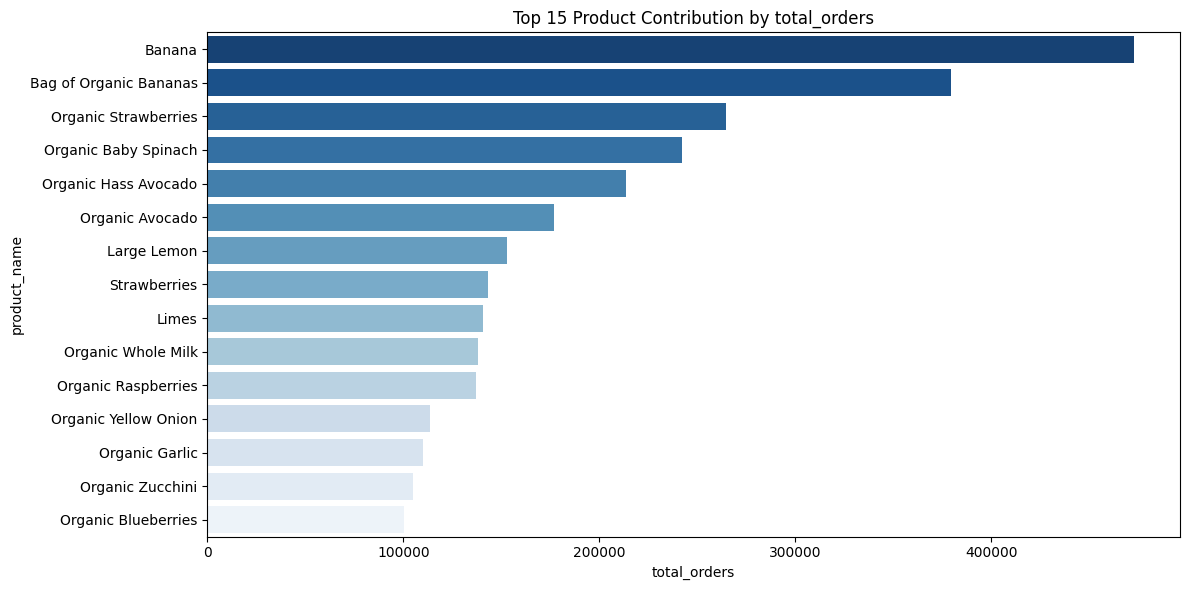

===== DEPARTMENT SALES PERFORMANCE ANALYSIS =====


C:\Users\geeth\AppData\Local\Temp\ipykernel_15776\2699448375.py:31: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(q.as_string(conn), conn)


,department,total_orders,department_share_pct
19,produce,9479291,29.2260
7,dairy eggs,5414016,16.6922
20,snacks,2887550,8.9027
3,beverages,2690129,8.2940
10,frozen,2236432,6.8952
16,pantry,1875577,5.7827
2,bakery,1176787,3.6282
6,canned goods,1068058,3.2930
8,deli,1051249,3.2411
9,dry goods pasta,866627,2.6719


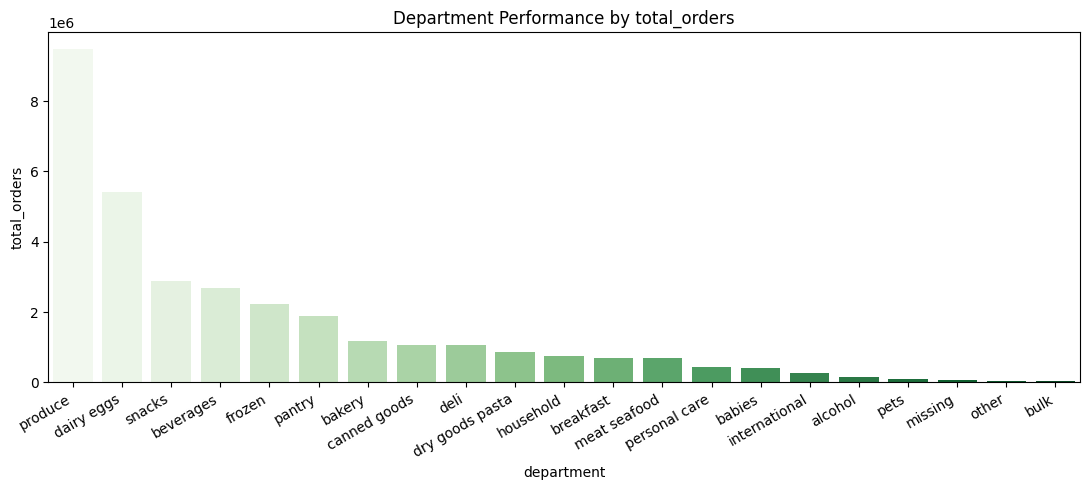

===== ORDER VOLUME TREND ANALYSIS (HOURLY) =====


C:\Users\geeth\AppData\Local\Temp\ipykernel_15776\2699448375.py:31: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(q.as_string(conn), conn)


,order_hour_of_day,total_orders
0,0,21372
1,1,11596
2,2,7070
3,3,5120
4,4,5175
5,5,8972
6,6,28792
7,7,86656
8,8,168321
9,9,243496


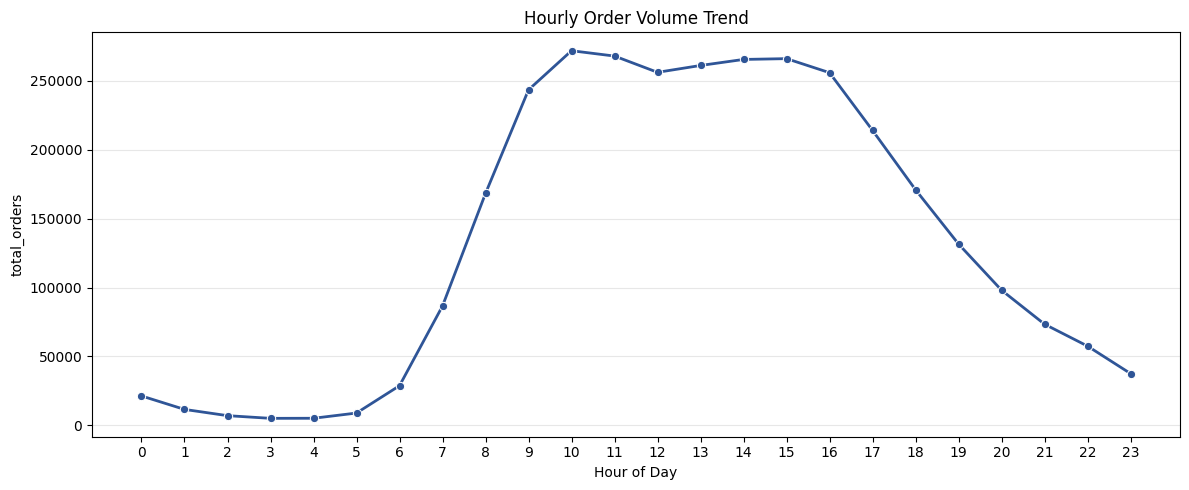


Reusable outputs created:
- top_products_contribution_df
- department_sales_performance_df
- order_volume_hourly_df


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from psycopg2 import sql

SCHEMA_NAME = "public"
TOP_N = 15

if "get_connection" not in globals():
    def get_connection():
        import psycopg2

        return psycopg2.connect(
            dbname="Instacart_Dw",
            user="postgres",
            password="root123"
        )

def pick_existing_column(df: pd.DataFrame, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def fetch_matview(conn, view_name: str):
    q = sql.SQL("SELECT * FROM {}.{};").format(
        sql.Identifier(SCHEMA_NAME),
        sql.Identifier(view_name),
    )
    return pd.read_sql_query(q.as_string(conn), conn)

conn = get_connection()

# -------------------------------
# 1) Top Product Contribution
# -------------------------------
product_df = fetch_matview(conn, "mv_product_performance_v2")

product_name_col = pick_existing_column(product_df, ["product_name", "product", "name"])
product_metric_col = pick_existing_column(
    product_df,
    ["total_orders", "product_orders", "orders", "order_count", "sales", "total_sales"],
)

if product_name_col is None or product_metric_col is None:
    print("Top Product Contribution: required columns not found in mv_product_performance_v2.")
else:
    prod = product_df[[product_name_col, product_metric_col]].copy()
    prod = prod.dropna(subset=[product_metric_col])
    prod[product_metric_col] = pd.to_numeric(prod[product_metric_col], errors="coerce")
    prod = prod.dropna(subset=[product_metric_col])
    prod = prod.groupby(product_name_col, as_index=False)[product_metric_col].sum()
    prod = prod.sort_values(product_metric_col, ascending=False)

    total_metric = prod[product_metric_col].sum()
    if total_metric > 0:
        prod["contribution_pct"] = (prod[product_metric_col] / total_metric) * 100
    else:
        prod["contribution_pct"] = 0.0
    prod["cumulative_contribution_pct"] = prod["contribution_pct"].cumsum()

    top_products_contribution_df = prod.head(TOP_N).copy()

    print("===== TOP PRODUCT CONTRIBUTION ANALYSIS =====")
    display(top_products_contribution_df[[product_name_col, product_metric_col, "contribution_pct", "cumulative_contribution_pct"]])

    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=top_products_contribution_df,
        x=product_metric_col,
        y=product_name_col,
        hue=product_name_col,
        dodge=False,
        palette="Blues_r",
        legend=False,
    )
    plt.title(f"Top {TOP_N} Product Contribution by {product_metric_col}")
    plt.xlabel(product_metric_col)
    plt.ylabel(product_name_col)
    plt.tight_layout()
    plt.show()

# -------------------------------------
# 2) Department Sales Performance
# -------------------------------------
dept_df = fetch_matview(conn, "mv_department_performance_v2")

dept_name_col = pick_existing_column(dept_df, ["department", "department_name", "name"])
dept_metric_col = pick_existing_column(
    dept_df,
    ["total_orders", "department_orders", "orders", "order_count", "sales", "total_sales"],
)

if dept_name_col is None or dept_metric_col is None:
    print("Department Sales Performance: required columns not found in mv_department_performance_v2.")
else:
    dep = dept_df[[dept_name_col, dept_metric_col]].copy()
    dep = dep.dropna(subset=[dept_metric_col])
    dep[dept_metric_col] = pd.to_numeric(dep[dept_metric_col], errors="coerce")
    dep = dep.dropna(subset=[dept_metric_col])
    dep = dep.groupby(dept_name_col, as_index=False)[dept_metric_col].sum()
    dep = dep.sort_values(dept_metric_col, ascending=False)

    dep_total = dep[dept_metric_col].sum()
    if dep_total > 0:
        dep["department_share_pct"] = (dep[dept_metric_col] / dep_total) * 100
    else:
        dep["department_share_pct"] = 0.0

    department_sales_performance_df = dep.copy()

    print("===== DEPARTMENT SALES PERFORMANCE ANALYSIS =====")
    display(department_sales_performance_df[[dept_name_col, dept_metric_col, "department_share_pct"]])

    plt.figure(figsize=(11, 5))
    sns.barplot(
        data=department_sales_performance_df,
        x=dept_name_col,
        y=dept_metric_col,
        hue=dept_name_col,
        dodge=False,
        palette="Greens",
        legend=False,
    )
    plt.title(f"Department Performance by {dept_metric_col}")
    plt.xlabel(dept_name_col)
    plt.ylabel(dept_metric_col)
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()

# -------------------------------------
# 3) Order Volume Trend Analysis (Hourly)
# -------------------------------------
time_df = fetch_matview(conn, "mv_orders_time_v2")

hour_col = pick_existing_column(time_df, ["order_hour_of_day", "hour", "order_hour"])
hour_orders_col = pick_existing_column(
    time_df,
    ["total_orders", "orders", "order_count", "cnt_orders"],
)

if hour_col is None or hour_orders_col is None:
    print("Order Volume Trend (Hourly): required columns not found in mv_orders_time_v2.")
else:
    hourly = time_df[[hour_col, hour_orders_col]].copy()
    hourly[hour_col] = pd.to_numeric(hourly[hour_col], errors="coerce")
    hourly[hour_orders_col] = pd.to_numeric(hourly[hour_orders_col], errors="coerce")
    hourly = hourly.dropna(subset=[hour_col, hour_orders_col])
    hourly = hourly.groupby(hour_col, as_index=False)[hour_orders_col].sum()
    hourly = hourly.sort_values(hour_col)

    order_volume_hourly_df = hourly.copy()

    print("===== ORDER VOLUME TREND ANALYSIS (HOURLY) =====")
    display(order_volume_hourly_df)

    plt.figure(figsize=(12, 5))
    sns.lineplot(
        data=order_volume_hourly_df,
        x=hour_col,
        y=hour_orders_col,
        marker="o",
        linewidth=2,
        color="#2F5597",
    )
    plt.title("Hourly Order Volume Trend")
    plt.xlabel("Hour of Day")
    plt.ylabel(hour_orders_col)
    plt.xticks(range(0, 24, 1))
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

conn.close()

print("\nReusable outputs created:")
print("- top_products_contribution_df")
print("- department_sales_performance_df")
print("- order_volume_hourly_df")

In [10]:
# KPI display from overview materialized view
import pandas as pd
from psycopg2 import sql

SCHEMA_NAME = "public"
KPI_VIEW = "mv_overview_kpis_v2"

if "get_connection" not in globals():
    def get_connection():
        import psycopg2

        return psycopg2.connect(
            dbname="Instacart_Dw",
            user="postgres",
            password="root123"
        )

def format_kpi_value(v):
    if pd.isna(v):
        return "NA"
    if isinstance(v, (int, float)):
        if abs(float(v)) >= 1000:
            return f"{float(v):,.0f}"
        return f"{float(v):,.4f}"
    return str(v)

conn = get_connection()
query = sql.SQL("SELECT * FROM {}.{};").format(
    sql.Identifier(SCHEMA_NAME),
    sql.Identifier(KPI_VIEW),
)
kpi_df = pd.read_sql_query(query.as_string(conn), conn)
conn.close()

print("===== OVERVIEW KPIs =====")
if kpi_df.empty:
    print("No KPI rows found in mv_overview_kpis_v2.")
else:
    # If multiple rows exist, keep the latest row shape by taking the first row for dashboard-style KPIs.
    kpi_row = kpi_df.iloc[0]
    kpi_display_df = pd.DataFrame({
        "kpi_name": kpi_row.index,
        "kpi_value": [format_kpi_value(v) for v in kpi_row.values],
    })
    display(kpi_display_df)

===== OVERVIEW KPIs =====


C:\Users\geeth\AppData\Local\Temp\ipykernel_15776\1822981585.py:32: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  kpi_df = pd.read_sql_query(query.as_string(conn), conn)


,kpi_name,kpi_value
0,total_orders,"3,214,874"
1,total_users,"206,209"
2,total_products,"49,677"
3,overall_reorder_rate,0.5897


In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Ensure src imports work whether notebook is run from root or notebooks/.
cwd = Path.cwd().resolve()
root = cwd.parent if cwd.name.lower() == "notebooks" else cwd
src_path = root / "src"
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

from db import get_connection


def run_sql(query: str) -> pd.DataFrame:
    with get_connection() as conn:
        return pd.read_sql_query(query, conn)

print("SQL helper ready for customer and reorder analysis (materialized views).")

SQL helper ready for customer and reorder analysis (materialized views).


C:\Users\geeth\AppData\Local\Temp\ipykernel_10160\2726736819.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, conn)


Overall Reorder KPI


,total_line_items,reordered_line_items,reorder_rate_pct
0,32434489.0,19126536.0,58.97


Departments by Reorder Rate


,department,line_items,reordered_items,reorder_rate_pct
0,dairy eggs,5414016,3627221,67.00
1,beverages,2690129,1757892,65.35
2,produce,9479291,6160710,64.99
3,bakery,1176787,739188,62.81
4,deli,1051249,638864,60.77
5,pets,97724,58760,60.13
6,babies,423802,245369,57.90
7,bulk,34573,19950,57.70
8,snacks,2887550,1657973,57.42
9,alcohol,153696,87595,56.99


Top Repeat Products (min 200 line items)


,product_name,line_items,reordered_items,reorder_rate_pct
0,Real2 Alkalized Water 500 ml,451,389,86.25
1,Half And Half Ultra Pasteurized,2921,2517,86.17
2,Whole Organic Omega 3 Milk,9108,7835,86.02
3,Organic Lactose Free Whole Milk,8477,7282,85.90
4,Organic Homogenized Whole Milk,3970,3405,85.77
5,Ultra-Purified Water,1489,1277,85.76
6,Lo-Carb Energy Drink,467,400,85.65
7,"Milk, Organic, Vitamin D",20198,17256,85.43
8,Organic Reduced Fat Milk,35663,30338,85.07
9,Goat Milk,5185,4407,85.00


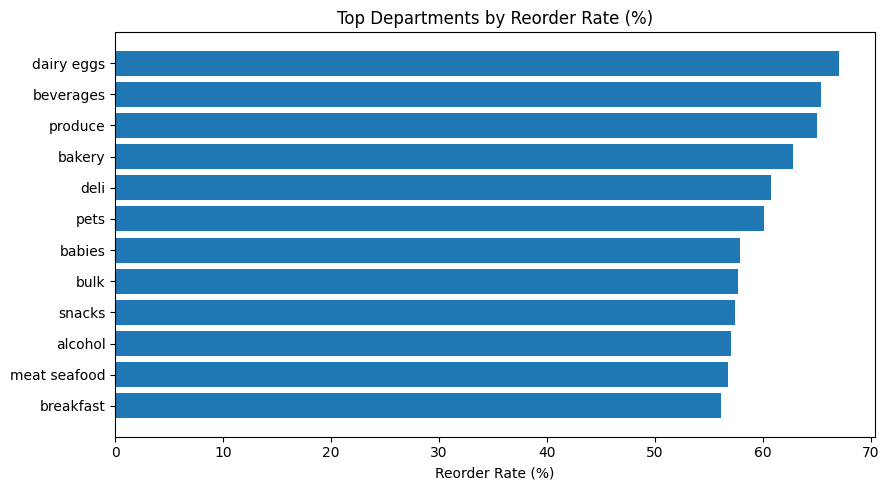

In [2]:
overall_reorder_q = """
SELECT
    SUM(total_count) AS total_line_items,
    SUM(CASE WHEN reordered = 1 THEN total_count ELSE 0 END) AS reordered_line_items,
    ROUND(100.0 * SUM(CASE WHEN reordered = 1 THEN total_count ELSE 0 END)::numeric / NULLIF(SUM(total_count), 0), 2) AS reorder_rate_pct
FROM mv_reorder_rate;
"""

reorder_by_department_q = """
SELECT
    department,
    total_orders AS line_items,
    reorder_count AS reordered_items,
    ROUND(reorder_rate * 100, 2) AS reorder_rate_pct
FROM mv_reorder_department_v2
ORDER BY reorder_rate DESC, total_orders DESC;
"""

reorder_by_product_q = """
SELECT
    product_name,
    total_orders AS line_items,
    reorder_count AS reordered_items,
    ROUND(reorder_rate * 100, 2) AS reorder_rate_pct
FROM mv_reorder_product_v2
WHERE total_orders >= 200
ORDER BY reorder_rate DESC, total_orders DESC
LIMIT 20;
"""

overall_reorder_df = run_sql(overall_reorder_q)
reorder_department_df = run_sql(reorder_by_department_q)
reorder_product_df = run_sql(reorder_by_product_q)

print("Overall Reorder KPI")
display(overall_reorder_df)

print("Departments by Reorder Rate")
display(reorder_department_df.head(15))

print("Top Repeat Products (min 200 line items)")
display(reorder_product_df)

plot_df = reorder_department_df.head(12).sort_values("reorder_rate_pct", ascending=True)
plt.figure(figsize=(9, 5))
plt.barh(plot_df["department"], plot_df["reorder_rate_pct"])
plt.title("Top Departments by Reorder Rate (%)")
plt.xlabel("Reorder Rate (%)")
plt.tight_layout()
plt.show()

C:\Users\geeth\AppData\Local\Temp\ipykernel_10160\2726736819.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, conn)


Reorder behavior by hour


,order_hour_of_day,line_items,reordered_items,reorder_rate_pct,order_count,behavior_segment
0,0,218948,123815,56.55,21372,Medium repeat tendency
1,1,115786,64506,55.71,11596,Medium repeat tendency
2,2,69434,38498,55.45,7070,Medium repeat tendency
3,3,51321,28714,55.95,5120,Medium repeat tendency
4,4,53283,30435,57.12,5175,Medium repeat tendency
5,5,88062,53537,60.79,8972,High repeat tendency
6,6,290795,185090,63.65,28792,High repeat tendency
7,7,891937,574829,64.45,86656,High repeat tendency
8,8,1719973,1086821,63.19,168321,High repeat tendency
9,9,2456713,1521808,61.94,243496,High repeat tendency


Hourly behavior segments


,behavior_segment,hour_count,avg_reorder_rate_pct,avg_order_volume
0,Low repeat tendency,0,NaN,NaN
1,Medium repeat tendency,12,57.06,114831.08
2,High repeat tendency,12,60.40,153075.08


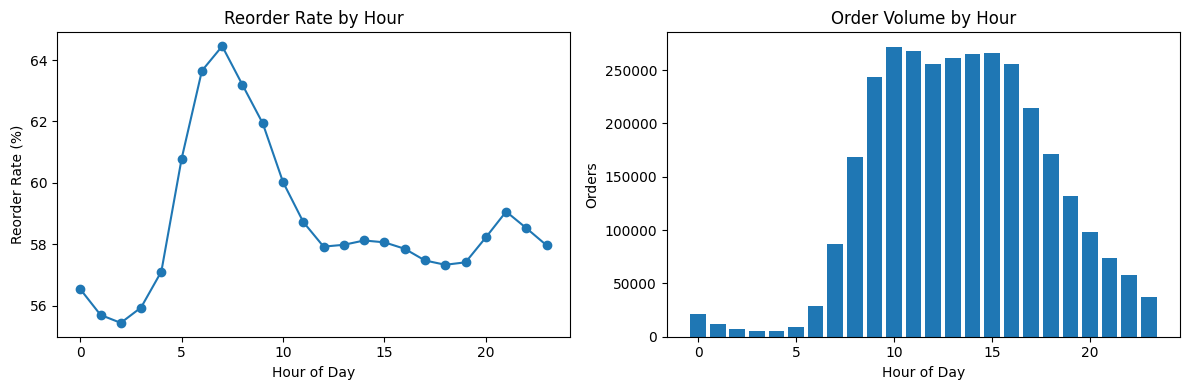

In [3]:
reorder_by_hour_q = """
SELECT
    order_hour_of_day,
    total_orders AS line_items,
    reorder_count AS reordered_items,
    ROUND(reorder_rate * 100, 2) AS reorder_rate_pct
FROM mv_reorder_time_v2
ORDER BY order_hour_of_day;
"""

orders_by_hour_q = """
SELECT
    order_hour_of_day,
    total_orders AS order_count
FROM mv_orders_time_v2
ORDER BY order_hour_of_day;
"""

reorder_hour_df = run_sql(reorder_by_hour_q)
orders_hour_df = run_sql(orders_by_hour_q)

behavior_df = reorder_hour_df.merge(orders_hour_df, on="order_hour_of_day", how="left")

# Segment hours by reorder tendency for behavior interpretation.
behavior_df["behavior_segment"] = pd.cut(
    behavior_df["reorder_rate_pct"],
    bins=[-1, 50, 58, 100],
    labels=["Low repeat tendency", "Medium repeat tendency", "High repeat tendency"],
)

print("Reorder behavior by hour")
display(behavior_df)

hourly_segment_summary = (
    behavior_df.groupby("behavior_segment", observed=False)
    .agg(
        hour_count=("order_hour_of_day", "count"),
        avg_reorder_rate_pct=("reorder_rate_pct", "mean"),
        avg_order_volume=("order_count", "mean"),
    )
    .reset_index()
)
hourly_segment_summary["avg_reorder_rate_pct"] = hourly_segment_summary["avg_reorder_rate_pct"].round(2)
hourly_segment_summary["avg_order_volume"] = hourly_segment_summary["avg_order_volume"].round(2)

print("Hourly behavior segments")
display(hourly_segment_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(behavior_df["order_hour_of_day"], behavior_df["reorder_rate_pct"], marker="o")
axes[0].set_title("Reorder Rate by Hour")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Reorder Rate (%)")

axes[1].bar(behavior_df["order_hour_of_day"], behavior_df["order_count"])
axes[1].set_title("Order Volume by Hour")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Orders")

plt.tight_layout()
plt.show()

C:\Users\geeth\AppData\Local\Temp\ipykernel_10160\2726736819.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, conn)


Department Loyalty Insights


,department,total_orders,reorder_count,reorder_rate_pct,loyalty_band
0,dairy eggs,5414016,3627221,67.00,High Loyalty Department
1,beverages,2690129,1757892,65.35,High Loyalty Department
2,produce,9479291,6160710,64.99,Medium Loyalty Department
3,bakery,1176787,739188,62.81,Medium Loyalty Department
4,deli,1051249,638864,60.77,Medium Loyalty Department
5,pets,97724,58760,60.13,Medium Loyalty Department
6,babies,423802,245369,57.90,Medium Loyalty Department
7,bulk,34573,19950,57.70,Medium Loyalty Department
8,snacks,2887550,1657973,57.42,Medium Loyalty Department
9,alcohol,153696,87595,56.99,Medium Loyalty Department


Department Loyalty Summary


,loyalty_band,department_count,avg_reorder_rate_pct,total_orders
0,High Loyalty Department,2,66.18,8104145
1,Low Loyalty Department,8,39.52,5370740
2,Medium Loyalty Department,11,58.71,18959604


Product Loyalty Summary


,product_loyalty_band,product_count,avg_reorder_rate_pct,total_orders
0,Champion Product,275,78.29,4241970
1,Low Loyalty Product,37393,29.52,5516883
2,Loyal Product,3700,66.25,12904980
3,Potential Loyal Product,8309,54.16,9770656


Top Champion/Loyal Products


,product_id,product_name,total_orders,reorder_count,reorder_rate_pct,product_loyalty_band
29,35496,Real2 Alkalized Water 500 ml,451,389,86.25,Loyal Product
31,9292,Half And Half Ultra Pasteurized,2921,2517,86.17,Champion Product
34,45504,Whole Organic Omega 3 Milk,9108,7835,86.02,Champion Product
36,43394,Organic Lactose Free Whole Milk,8477,7282,85.90,Champion Product
38,5514,Organic Homogenized Whole Milk,3970,3405,85.77,Champion Product
39,47231,Ultra-Purified Water,1489,1277,85.76,Champion Product
48,17469,Lo-Carb Energy Drink,467,400,85.65,Loyal Product
51,29447,"Milk, Organic, Vitamin D",20198,17256,85.43,Champion Product
54,38689,Organic Reduced Fat Milk,35663,30338,85.07,Champion Product
55,34197,Goat Milk,5185,4407,85.00,Champion Product


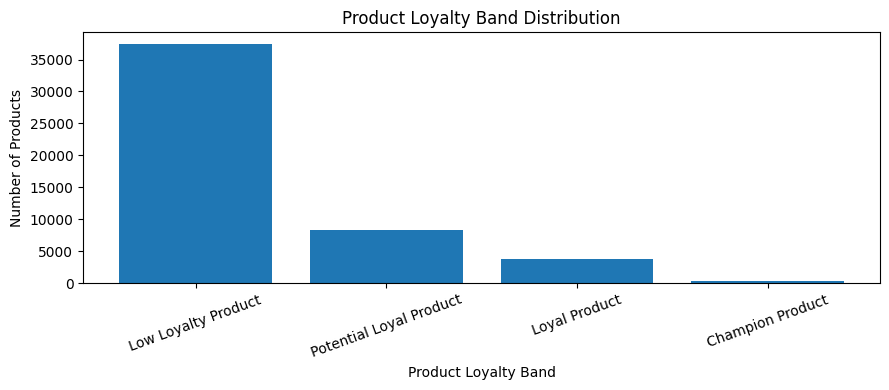

In [4]:
dept_loyalty_q = """
SELECT
    department,
    total_orders,
    reorder_count,
    ROUND(reorder_rate * 100, 2) AS reorder_rate_pct,
    CASE
        WHEN reorder_rate >= 0.65 THEN 'High Loyalty Department'
        WHEN reorder_rate >= 0.50 THEN 'Medium Loyalty Department'
        ELSE 'Low Loyalty Department'
    END AS loyalty_band
FROM mv_reorder_department_v2
ORDER BY reorder_rate DESC, total_orders DESC;
"""

product_loyalty_q = """
SELECT
    product_id,
    product_name,
    total_orders,
    reorder_count,
    ROUND(reorder_rate * 100, 2) AS reorder_rate_pct,
    CASE
        WHEN reorder_rate >= 0.75 AND total_orders >= 500 THEN 'Champion Product'
        WHEN reorder_rate >= 0.60 AND total_orders >= 200 THEN 'Loyal Product'
        WHEN reorder_rate >= 0.45 AND total_orders >= 100 THEN 'Potential Loyal Product'
        ELSE 'Low Loyalty Product'
    END AS product_loyalty_band
FROM mv_reorder_product_v2
ORDER BY reorder_rate DESC, total_orders DESC;
"""

department_loyalty_df = run_sql(dept_loyalty_q)
product_loyalty_df = run_sql(product_loyalty_q)

product_loyalty_summary = (
    product_loyalty_df.groupby("product_loyalty_band", observed=False)
    .agg(
        product_count=("product_id", "count"),
        avg_reorder_rate_pct=("reorder_rate_pct", "mean"),
        total_orders=("total_orders", "sum"),
    )
    .reset_index()
)
product_loyalty_summary["avg_reorder_rate_pct"] = product_loyalty_summary["avg_reorder_rate_pct"].round(2)

dept_loyalty_summary = (
    department_loyalty_df.groupby("loyalty_band", observed=False)
    .agg(
        department_count=("department", "count"),
        avg_reorder_rate_pct=("reorder_rate_pct", "mean"),
        total_orders=("total_orders", "sum"),
    )
    .reset_index()
)
dept_loyalty_summary["avg_reorder_rate_pct"] = dept_loyalty_summary["avg_reorder_rate_pct"].round(2)

print("Department Loyalty Insights")
display(department_loyalty_df.head(20))

print("Department Loyalty Summary")
display(dept_loyalty_summary)

print("Product Loyalty Summary")
display(product_loyalty_summary)

print("Top Champion/Loyal Products")
display(
    product_loyalty_df[
        product_loyalty_df["product_loyalty_band"].isin(["Champion Product", "Loyal Product"])
    ].head(20)
)

plt.figure(figsize=(9, 4))
plot_df = product_loyalty_summary.sort_values("product_count", ascending=False)
plt.bar(plot_df["product_loyalty_band"], plot_df["product_count"])
plt.title("Product Loyalty Band Distribution")
plt.xlabel("Product Loyalty Band")
plt.ylabel("Number of Products")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Department Action Segments


C:\Users\geeth\AppData\Local\Temp\ipykernel_10160\2726736819.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, conn)


,department,total_orders,order_share_pct,reorder_rate_pct,vs_global_rate_pct,potential_reorders_if_at_global,action_segment
0,produce,9479291,29.23,64.99,6.02,-570677.0,Defend
1,dairy eggs,5414016,16.69,67.00,8.03,-434759.0,Defend
2,snacks,2887550,8.90,57.42,-1.55,44750.0,Fix First
3,beverages,2690129,8.29,65.35,6.38,-171637.0,Defend
4,frozen,2236432,6.90,54.19,-4.78,106896.0,Fix First
5,pantry,1875577,5.78,34.67,-24.30,455760.0,Fix First
6,bakery,1176787,3.63,62.81,3.84,-45192.0,Defend
7,canned goods,1068058,3.29,45.74,-13.23,141301.0,Fix First
8,deli,1051249,3.24,60.77,1.80,-18925.0,Defend
9,dry goods pasta,866627,2.67,46.11,-12.86,111446.0,Fix First


Segment Summary


,action_segment,department_count,total_orders,avg_reorder_rate_pct,total_uplift_reorders
0,Defend,5,19811472,64.18,0.0
1,Fix First,6,9672910,46.39,998651.0
2,Grow Selectively,1,97724,60.13,0.0
3,Niche Monitor,9,2852383,48.32,243512.0


Priority View (Fix First and Defend)


,department,action_segment,total_orders,order_share_pct,reorder_rate_pct,vs_global_rate_pct,potential_reorders_if_at_global
8,deli,Defend,1051249,3.24,60.77,1.80,-18925.0
6,bakery,Defend,1176787,3.63,62.81,3.84,-45192.0
3,beverages,Defend,2690129,8.29,65.35,6.38,-171637.0
1,dairy eggs,Defend,5414016,16.69,67.00,8.03,-434759.0
0,produce,Defend,9479291,29.23,64.99,6.02,-570677.0
5,pantry,Fix First,1875577,5.78,34.67,-24.30,455760.0
7,canned goods,Fix First,1068058,3.29,45.74,-13.23,141301.0
10,household,Fix First,738666,2.28,40.22,-18.75,138498.0
9,dry goods pasta,Fix First,866627,2.67,46.11,-12.86,111446.0
4,frozen,Fix First,2236432,6.90,54.19,-4.78,106896.0


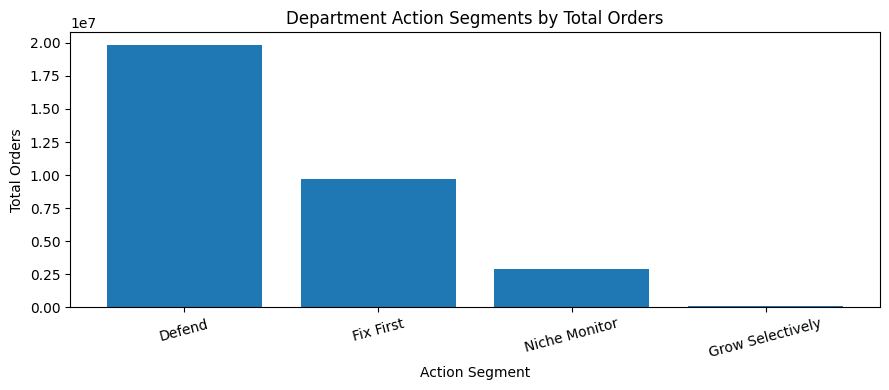

In [5]:
department_action_q = """
WITH d AS (
    SELECT
        department,
        total_orders,
        reorder_count,
        reorder_rate
    FROM mv_reorder_department_v2
),
base AS (
    SELECT
        SUM(total_orders) AS all_orders,
        SUM(reorder_count)::numeric / NULLIF(SUM(total_orders), 0) AS global_reorder_rate,
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY total_orders) AS median_orders
    FROM d
)
SELECT
    d.department,
    d.total_orders,
    ROUND(100.0 * d.total_orders::numeric / b.all_orders, 2) AS order_share_pct,
    ROUND(d.reorder_rate * 100, 2) AS reorder_rate_pct,
    ROUND((d.reorder_rate - b.global_reorder_rate) * 100, 2) AS vs_global_rate_pct,
    ROUND(((b.global_reorder_rate - d.reorder_rate) * d.total_orders), 0) AS potential_reorders_if_at_global,
    CASE
        WHEN d.total_orders >= b.median_orders AND d.reorder_rate >= b.global_reorder_rate THEN 'Defend'
        WHEN d.total_orders >= b.median_orders AND d.reorder_rate < b.global_reorder_rate THEN 'Fix First'
        WHEN d.total_orders < b.median_orders AND d.reorder_rate < b.global_reorder_rate THEN 'Niche Monitor'
        ELSE 'Grow Selectively'
    END AS action_segment
FROM d
CROSS JOIN base b
ORDER BY d.total_orders DESC;
"""

department_action_df = run_sql(department_action_q)

segment_summary_df = (
    department_action_df.groupby("action_segment", observed=False)
    .agg(
        department_count=("department", "count"),
        total_orders=("total_orders", "sum"),
        avg_reorder_rate_pct=("reorder_rate_pct", "mean"),
        total_uplift_reorders=("potential_reorders_if_at_global", lambda s: s[s > 0].sum()),
    )
    .reset_index()
)
segment_summary_df["avg_reorder_rate_pct"] = segment_summary_df["avg_reorder_rate_pct"].round(2)

priority_df = department_action_df[
    department_action_df["action_segment"].isin(["Fix First", "Defend"])
].copy()
priority_df = priority_df.sort_values(
    ["action_segment", "potential_reorders_if_at_global", "total_orders"],
    ascending=[True, False, False],
)

print("Department Action Segments")
display(department_action_df)

print("Segment Summary")
display(segment_summary_df)

print("Priority View (Fix First and Defend)")
display(priority_df[[
    "department",
    "action_segment",
    "total_orders",
    "order_share_pct",
    "reorder_rate_pct",
    "vs_global_rate_pct",
    "potential_reorders_if_at_global",
]])

plot_df = segment_summary_df.sort_values("total_orders", ascending=False)
plt.figure(figsize=(9, 4))
plt.bar(plot_df["action_segment"], plot_df["total_orders"])
plt.title("Department Action Segments by Total Orders")
plt.xlabel("Action Segment")
plt.ylabel("Total Orders")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

C:\Users\geeth\AppData\Local\Temp\ipykernel_10160\2726736819.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, conn)


Basket Summary


,metric,value
0,total_orders,3214874.00
1,avg_basket_size,10.09
2,median_basket_size,8.00
3,p75_basket_size,14.00
4,p90_basket_size,20.00
5,max_basket_size,145.00


Basket Segment Contribution


,basket_segment,order_count,avg_basket_size,total_items,order_share_pct,item_share_pct
0,Small (1-5 items),1001179,3.18,3181789.0,31.14,9.81
1,Medium (6-15 items),1592191,9.67,15394283.0,49.53,47.46
2,Large (16+ items),621504,22.30,13858417.0,19.33,42.73


Basket Size Distribution (first 20 sizes)


,basket_size,order_count,order_share_pct,cum_order_share_pct
0,1,156748,4.8757,4.88
1,2,186993,5.8165,10.69
2,3,207027,6.4397,17.13
3,4,222081,6.9079,24.04
4,5,228330,7.1023,31.14
5,6,227675,7.0819,38.22
6,7,220006,6.8434,45.07
7,8,203374,6.3260,51.39
8,9,184347,5.7342,57.13
9,10,165550,5.1495,62.28


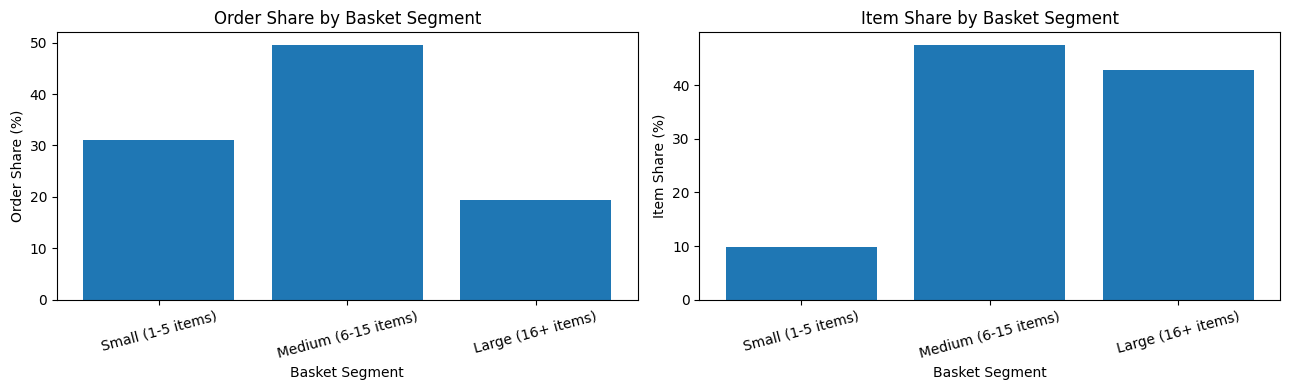

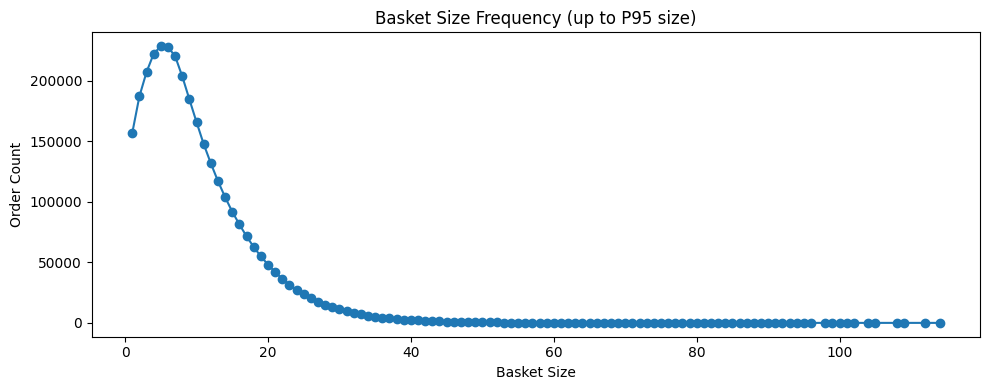

Insight: Small baskets contribute 31.14% of orders, while large baskets contribute 42.73% of total items.


In [7]:
basket_base_q = """
SELECT
    order_id,
    basket_size
FROM mv_basket_analysis_v2;
"""

basket_segment_q = """
WITH b AS (
    SELECT
        order_id,
        basket_size,
        CASE
            WHEN basket_size <= 5 THEN 'Small (1-5 items)'
            WHEN basket_size <= 15 THEN 'Medium (6-15 items)'
            ELSE 'Large (16+ items)'
        END AS basket_segment
    FROM mv_basket_analysis_v2
)
SELECT
    basket_segment,
    COUNT(*) AS order_count,
    ROUND(AVG(basket_size), 2) AS avg_basket_size,
    SUM(basket_size) AS total_items,
    ROUND(100.0 * COUNT(*)::numeric / SUM(COUNT(*)) OVER (), 2) AS order_share_pct,
    ROUND(100.0 * SUM(basket_size)::numeric / SUM(SUM(basket_size)) OVER (), 2) AS item_share_pct
FROM b
GROUP BY basket_segment
ORDER BY avg_basket_size;
"""

basket_df = run_sql(basket_base_q)
basket_segment_df = run_sql(basket_segment_q)

basket_summary_df = pd.DataFrame(
    {
        "metric": [
            "total_orders",
            "avg_basket_size",
            "median_basket_size",
            "p75_basket_size",
            "p90_basket_size",
            "max_basket_size",
        ],
        "value": [
            int(basket_df["order_id"].nunique()),
            round(float(basket_df["basket_size"].mean()), 2),
            round(float(basket_df["basket_size"].median()), 2),
            round(float(basket_df["basket_size"].quantile(0.75)), 2),
            round(float(basket_df["basket_size"].quantile(0.90)), 2),
            int(basket_df["basket_size"].max()),
        ],
    }
)

basket_distribution_df = (
    basket_df.groupby("basket_size", as_index=False)
    .agg(order_count=("order_id", "count"))
    .sort_values("basket_size")
)
basket_distribution_df["order_share_pct"] = (
    100.0 * basket_distribution_df["order_count"] / basket_distribution_df["order_count"].sum()
).round(4)
basket_distribution_df["cum_order_share_pct"] = basket_distribution_df["order_share_pct"].cumsum().round(2)

print("Basket Summary")
display(basket_summary_df)

print("Basket Segment Contribution")
display(basket_segment_df)

print("Basket Size Distribution (first 20 sizes)")
display(basket_distribution_df.head(20))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(basket_segment_df["basket_segment"], basket_segment_df["order_share_pct"])
axes[0].set_title("Order Share by Basket Segment")
axes[0].set_xlabel("Basket Segment")
axes[0].set_ylabel("Order Share (%)")
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(basket_segment_df["basket_segment"], basket_segment_df["item_share_pct"])
axes[1].set_title("Item Share by Basket Segment")
axes[1].set_xlabel("Basket Segment")
axes[1].set_ylabel("Item Share (%)")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plot_dist = basket_distribution_df[basket_distribution_df["basket_size"] <= basket_distribution_df["basket_size"].quantile(0.95)]
plt.plot(plot_dist["basket_size"], plot_dist["order_count"], marker="o")
plt.title("Basket Size Frequency (up to P95 size)")
plt.xlabel("Basket Size")
plt.ylabel("Order Count")
plt.tight_layout()
plt.show()

# Quick interpretation anchors.
small_share = float(basket_segment_df.loc[basket_segment_df["basket_segment"] == "Small (1-5 items)", "order_share_pct"].iloc[0])
large_item_share = float(basket_segment_df.loc[basket_segment_df["basket_segment"] == "Large (16+ items)", "item_share_pct"].iloc[0])
print(
    f"Insight: Small baskets contribute {small_share:.2f}% of orders, while large baskets contribute {large_item_share:.2f}% of total items."
)

C:\Users\geeth\AppData\Local\Temp\ipykernel_10160\2726736819.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, conn)
C:\Users\geeth\AppData\Local\Temp\ipykernel_10160\2726736819.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, conn)
C:\Users\geeth\AppData\Local\Temp\ipykernel_10160\2726736819.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, conn)
C:\Users\geeth\AppData\Local\Temp\ipykernel_10160\2726736819.py:18: UserW

Pareto Summary (80% cutoff)


,dimension,total_groups,groups_to_reach_80pct,share_of_groups_pct
0,Products,49677,4538,9.14
1,Departments,21,8,38.10
2,Order Hours,24,11,45.83
3,Basket Sizes,113,15,13.27


Top products with cumulative share


,product_name,total_orders,rank,value_share_pct,cum_share_pct
0,Banana,472565,1,1.456983,1.456983
1,Bag of Organic Bananas,379450,2,1.169897,2.626880
2,Organic Strawberries,264683,3,0.816054,3.442934
3,Organic Baby Spinach,241921,4,0.745876,4.188810
4,Organic Hass Avocado,213584,5,0.658509,4.847319
5,Organic Avocado,176815,6,0.545145,5.392464
6,Large Lemon,152657,7,0.470663,5.863126
7,Strawberries,142951,8,0.440738,6.303864
8,Limes,140627,9,0.433572,6.737436
9,Organic Whole Milk,137905,10,0.425180,7.162616


...

,department,total_orders,rank,value_share_pct,cum_share_pct
0,produce,9479291,1,29.225961,29.225961
1,dairy eggs,5414016,2,16.692158,45.918118
2,snacks,2887550,3,8.902715,54.820833
3,beverages,2690129,4,8.294038,63.114871
4,frozen,2236432,5,6.895228,70.010099
5,pantry,1875577,6,5.782662,75.792762
6,bakery,1176787,7,3.628197,79.420958
7,canned goods,1068058,8,3.292970,82.713928
8,deli,1051249,9,3.241146,85.955074
9,dry goods pasta,866627,10,2.671930,88.627004


Hour Pareto table


,order_hour_of_day,total_orders,rank,value_share_pct,cum_share_pct
0,10,271885,1,8.457097,8.457097
1,11,268006,2,8.336439,16.793535
2,15,266132,3,8.278147,25.071682
3,14,265556,4,8.260230,33.331913
4,13,261174,5,8.123926,41.455839
5,12,256206,6,7.969395,49.425234
6,16,255949,7,7.961401,57.386635
7,9,243496,8,7.574045,64.960680
8,17,214080,9,6.659048,71.619728
9,18,170998,10,5.318964,76.938692


Basket-size Pareto table (top 20 sizes)


,basket_size,order_count,rank,value_share_pct,cum_share_pct
0,5,228330,1,7.102300,7.102300
1,6,227675,2,7.081926,14.184226
2,4,222081,3,6.907922,21.092149
3,7,220006,4,6.843379,27.935527
4,3,207027,5,6.439661,34.375189
5,8,203374,6,6.326033,40.701222
6,2,186993,7,5.816495,46.517717
7,9,184347,8,5.734191,52.251908
8,10,165550,9,5.149502,57.401410
9,1,156748,10,4.875712,62.277122


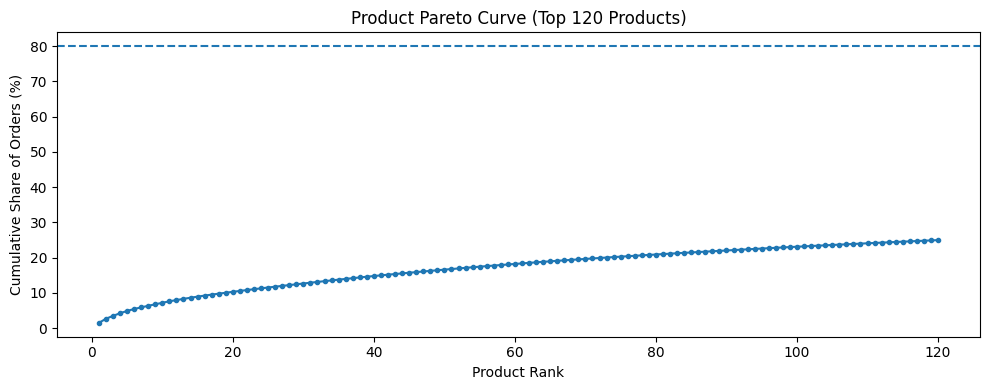

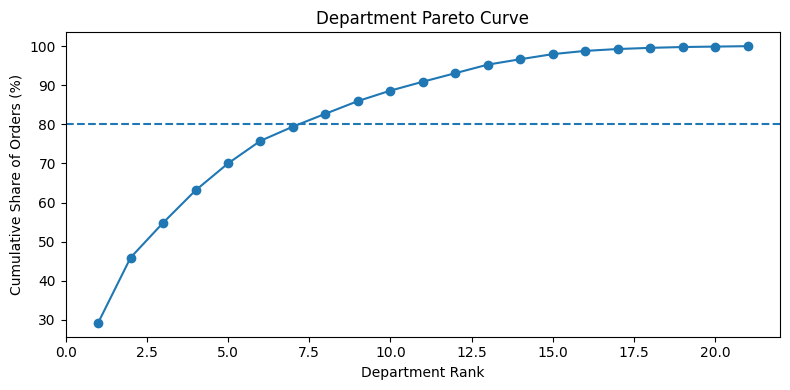

Note: user_id/gender Pareto is not possible in this warehouse because those columns are not available in current tables/materialized views.


In [8]:
def build_pareto(df: pd.DataFrame, group_col: str, value_col: str) -> pd.DataFrame:
    p = df[[group_col, value_col]].copy()
    p[value_col] = pd.to_numeric(p[value_col], errors="coerce")
    p = p.dropna(subset=[value_col])
    p = p.groupby(group_col, as_index=False)[value_col].sum()
    p = p.sort_values(value_col, ascending=False).reset_index(drop=True)
    p["rank"] = p.index + 1
    p["value_share_pct"] = 100.0 * p[value_col] / p[value_col].sum()
    p["cum_share_pct"] = p["value_share_pct"].cumsum()
    return p


def pareto_cutoff_count(pareto_df: pd.DataFrame, threshold: float = 80.0) -> int:
    hit = pareto_df[pareto_df["cum_share_pct"] >= threshold]
    return int(hit.iloc[0]["rank"]) if not hit.empty else int(len(pareto_df))


product_pareto = build_pareto(run_sql("SELECT product_name, total_orders FROM mv_product_performance_v2"), "product_name", "total_orders")
department_pareto = build_pareto(run_sql("SELECT department, total_orders FROM mv_department_performance_v2"), "department", "total_orders")
hour_pareto = build_pareto(run_sql("SELECT order_hour_of_day, total_orders FROM mv_orders_time_v2"), "order_hour_of_day", "total_orders")
basket_size_pareto = build_pareto(run_sql("SELECT basket_size, COUNT(*) AS order_count FROM mv_basket_analysis_v2 GROUP BY basket_size"), "basket_size", "order_count")

pareto_summary_df = pd.DataFrame(
    [
        {
            "dimension": "Products",
            "total_groups": int(len(product_pareto)),
            "groups_to_reach_80pct": pareto_cutoff_count(product_pareto, 80.0),
            "share_of_groups_pct": round(100.0 * pareto_cutoff_count(product_pareto, 80.0) / len(product_pareto), 2),
        },
        {
            "dimension": "Departments",
            "total_groups": int(len(department_pareto)),
            "groups_to_reach_80pct": pareto_cutoff_count(department_pareto, 80.0),
            "share_of_groups_pct": round(100.0 * pareto_cutoff_count(department_pareto, 80.0) / len(department_pareto), 2),
        },
        {
            "dimension": "Order Hours",
            "total_groups": int(len(hour_pareto)),
            "groups_to_reach_80pct": pareto_cutoff_count(hour_pareto, 80.0),
            "share_of_groups_pct": round(100.0 * pareto_cutoff_count(hour_pareto, 80.0) / len(hour_pareto), 2),
        },
        {
            "dimension": "Basket Sizes",
            "total_groups": int(len(basket_size_pareto)),
            "groups_to_reach_80pct": pareto_cutoff_count(basket_size_pareto, 80.0),
            "share_of_groups_pct": round(100.0 * pareto_cutoff_count(basket_size_pareto, 80.0) / len(basket_size_pareto), 2),
        },
    ]
)

print("Pareto Summary (80% cutoff)")
display(pareto_summary_df)

print("Top products with cumulative share")
display(product_pareto.head(20))

print("Department Pareto table")
display(department_pareto)

print("Hour Pareto table")
display(hour_pareto)

print("Basket-size Pareto table (top 20 sizes)")
display(basket_size_pareto.head(20))

# Product Pareto curve (top 120 products for readability).
plot_prod = product_pareto.head(120).copy()
plt.figure(figsize=(10, 4))
plt.plot(plot_prod["rank"], plot_prod["cum_share_pct"], marker=".")
plt.axhline(80, linestyle="--")
plt.title("Product Pareto Curve (Top 120 Products)")
plt.xlabel("Product Rank")
plt.ylabel("Cumulative Share of Orders (%)")
plt.tight_layout()
plt.show()

# Department Pareto curve.
plt.figure(figsize=(8, 4))
plt.plot(department_pareto["rank"], department_pareto["cum_share_pct"], marker="o")
plt.axhline(80, linestyle="--")
plt.title("Department Pareto Curve")
plt.xlabel("Department Rank")
plt.ylabel("Cumulative Share of Orders (%)")
plt.tight_layout()
plt.show()

print("Note: user_id/gender Pareto is not possible in this warehouse because those columns are not available in current tables/materialized views.")

C:\Users\geeth\AppData\Local\Temp\ipykernel_10160\2726736819.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, conn)


,reorder_type,total_count,share_pct
0,Reordered,19126536,58.969747
1,First-time / Not Reordered,13307953,41.030253


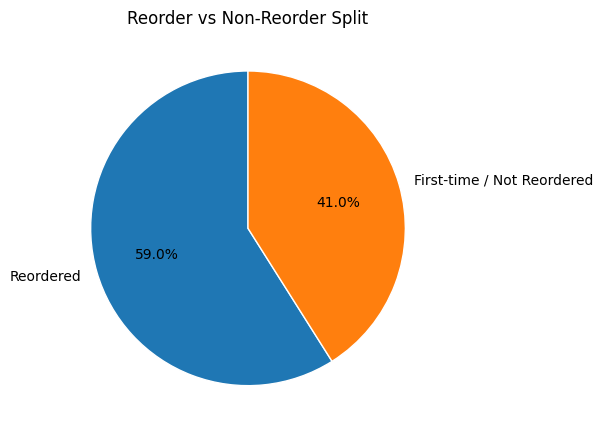

C:\Users\geeth\AppData\Local\Temp\ipykernel_10160\2726736819.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, conn)


,order_hour_of_day,total_orders,reorder_count,reorder_rate_pct
0,0,218948,123815,56.55
1,1,115786,64506,55.71
2,2,69434,38498,55.45
3,3,51321,28714,55.95
4,4,53283,30435,57.12
5,5,88062,53537,60.79
6,6,290795,185090,63.65
7,7,891937,574829,64.45
8,8,1719973,1086821,63.19
9,9,2456713,1521808,61.94


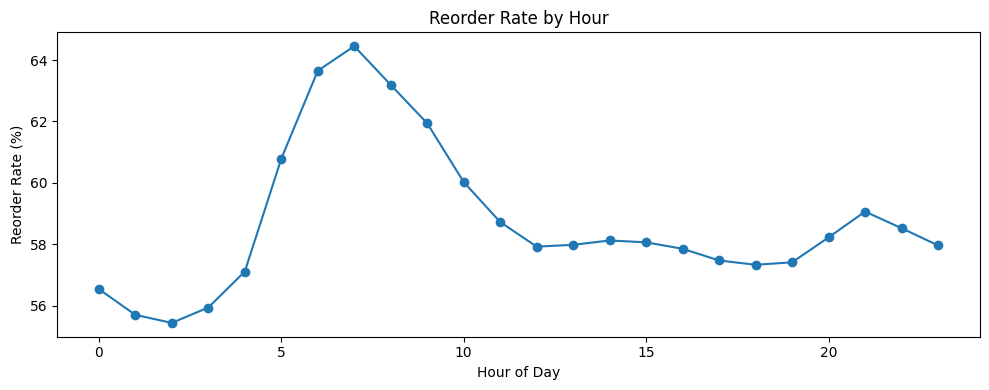

C:\Users\geeth\AppData\Local\Temp\ipykernel_10160\2726736819.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, conn)


,product_name,reorder_count,total_orders,reorder_rate
0,Banana,398609,472565,0.8435
1,Bag of Organic Bananas,315913,379450,0.8326
2,Organic Strawberries,205845,264683,0.7777
3,Organic Baby Spinach,186884,241921,0.7725
4,Organic Hass Avocado,170131,213584,0.7966
5,Organic Avocado,134044,176815,0.7581
6,Organic Whole Milk,114510,137905,0.8304
7,Large Lemon,106255,152657,0.6960
8,Organic Raspberries,105409,137057,0.7691
9,Strawberries,99802,142951,0.6982


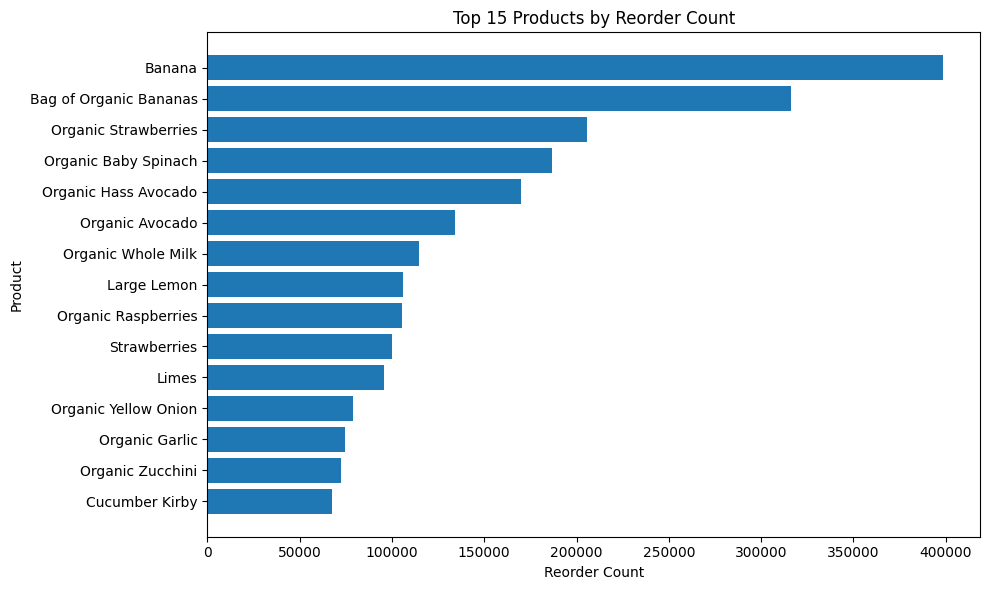

C:\Users\geeth\AppData\Local\Temp\ipykernel_10160\2726736819.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, conn)


,product_loyalty_band,product_count,avg_reorder_rate_pct,total_orders
0,Low Loyalty Product,37393,29.52,5516883.0
1,Potential Loyal Product,8309,54.16,9770656.0
2,Loyal Product,3700,66.25,12904980.0
3,Champion Product,275,78.29,4241970.0


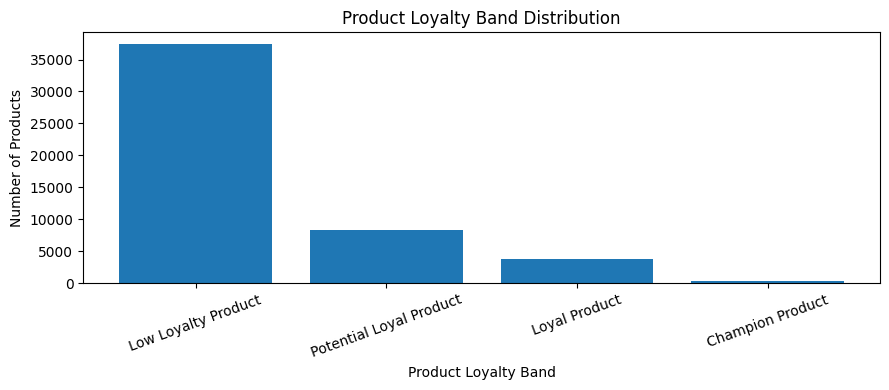

C:\Users\geeth\AppData\Local\Temp\ipykernel_10160\2726736819.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, conn)


,department,total_orders,reorder_count,reorder_rate_pct
0,dairy eggs,5414016,3627221,67.00
1,beverages,2690129,1757892,65.35
2,produce,9479291,6160710,64.99
3,bakery,1176787,739188,62.81
4,deli,1051249,638864,60.77
5,pets,97724,58760,60.13
6,babies,423802,245369,57.90
7,bulk,34573,19950,57.70
8,snacks,2887550,1657973,57.42
9,alcohol,153696,87595,56.99


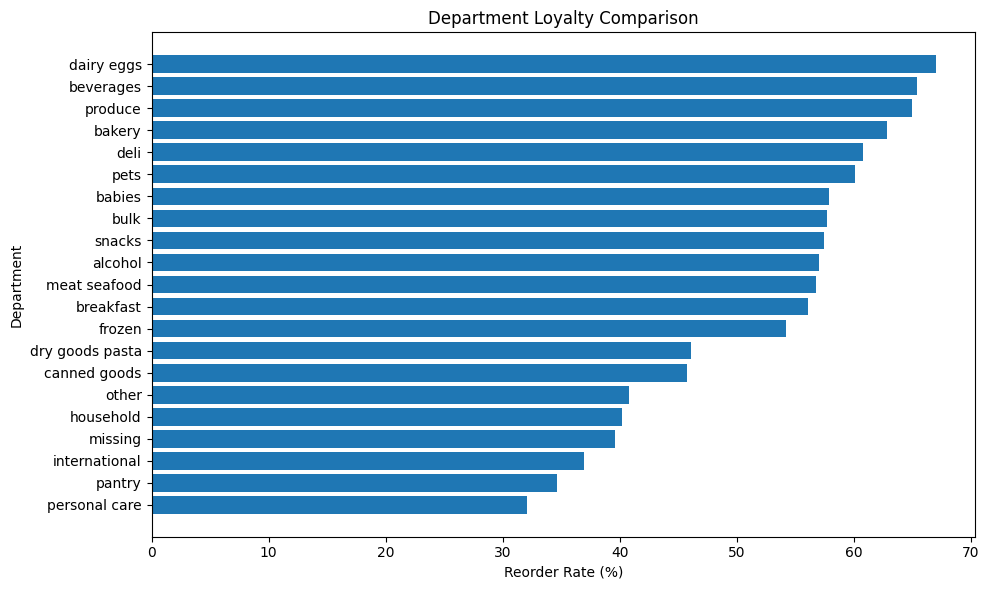

C:\Users\geeth\AppData\Local\Temp\ipykernel_10160\2726736819.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, conn)


,department,total_orders,order_share_pct,reorder_rate,gap_to_benchmark,action_segment
0,frozen,2236432,6.895228,0.5419,0.020824,Defend
1,other,36291,0.111890,0.4080,-0.113076,Niche Monitor
2,bakery,1176787,3.628197,0.6281,0.107024,Defend
3,produce,9479291,29.225961,0.6499,0.128824,Defend
4,alcohol,153696,0.473866,0.5699,0.048824,Grow Selectively
5,international,269253,0.830144,0.3692,-0.151876,Niche Monitor
6,beverages,2690129,8.294038,0.6535,0.132424,Defend
7,pets,97724,0.301297,0.6013,0.080224,Grow Selectively
8,dry goods pasta,866627,2.671930,0.4611,-0.059976,Fix First
9,bulk,34573,0.106593,0.5770,0.055924,Grow Selectively


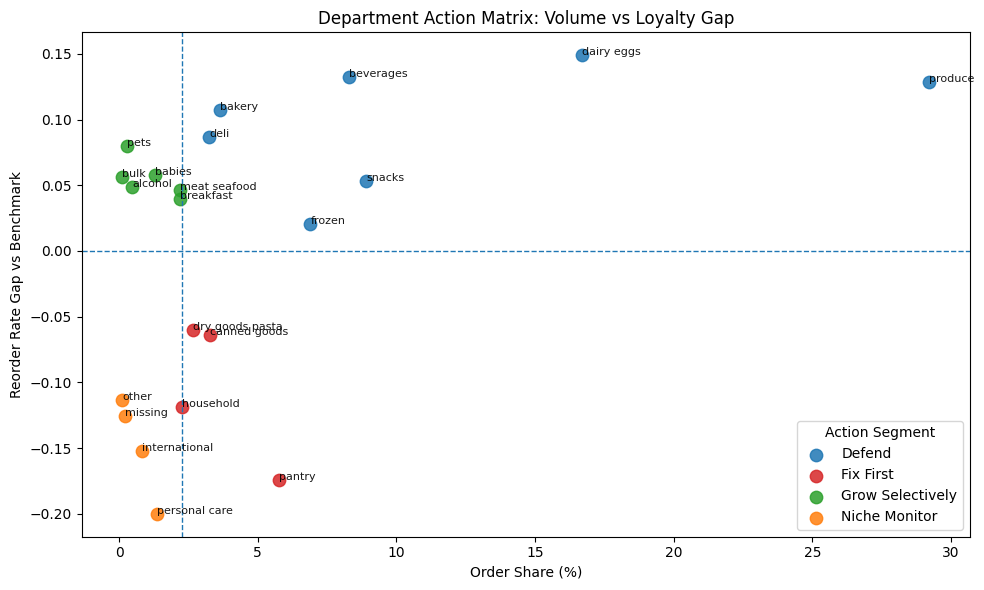

,department,total_orders,order_share_pct,reorder_rate,gap_to_benchmark,action_segment
0,pantry,1875577,5.782662,0.3467,-0.174376,Fix First
1,canned goods,1068058,3.292970,0.4574,-0.063676,Fix First
2,dry goods pasta,866627,2.671930,0.4611,-0.059976,Fix First
3,household,738666,2.277409,0.4022,-0.118876,Fix First


C:\Users\geeth\AppData\Local\Temp\ipykernel_10160\2726736819.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, conn)


,metric,value
0,total_orders,3214874.00
1,avg_basket_size,10.09
2,median_basket_size,8.00
3,p75_basket_size,14.00
4,p90_basket_size,20.00
5,max_basket_size,145.00


,basket_size,order_count
0,1,156748
1,2,186993
2,3,207027
3,4,222081
4,5,228330
5,6,227675
6,7,220006
7,8,203374
8,9,184347
9,10,165550


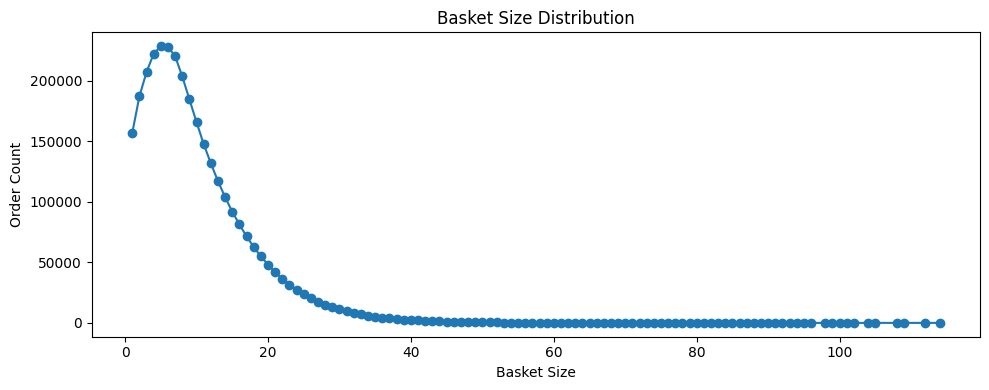

C:\Users\geeth\AppData\Local\Temp\ipykernel_10160\2726736819.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, conn)


,basket_segment,order_count,avg_basket_size,total_items,order_share_pct,item_share_pct
0,Small (1-5 items),1001179,3.18,3181789.0,31.14,9.81
1,Medium (6-15 items),1592191,9.67,15394283.0,49.53,47.46
2,Large (16+ items),621504,22.30,13858417.0,19.33,42.73


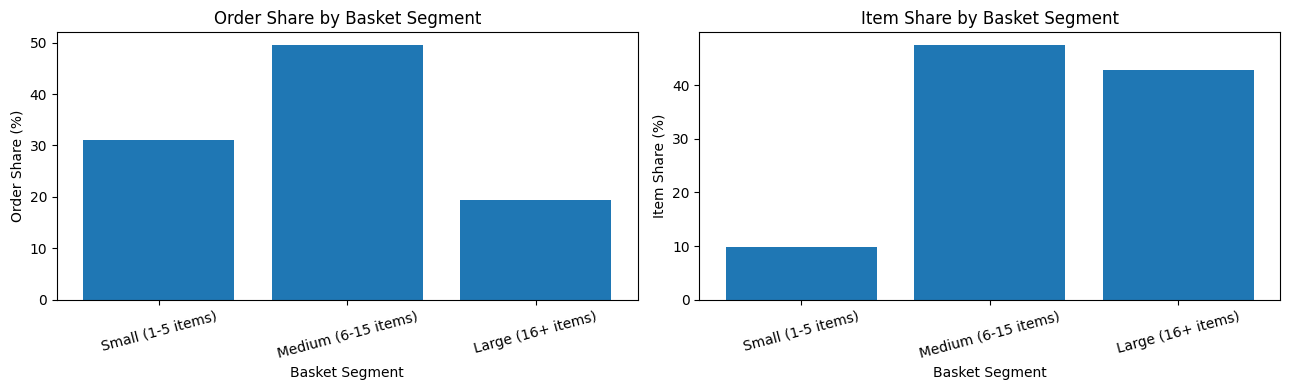

C:\Users\geeth\AppData\Local\Temp\ipykernel_10160\2726736819.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, conn)


,basket_size,order_count,rank,share_pct,cum_share_pct
0,5,228330,1,7.102300,7.102300
1,6,227675,2,7.081926,14.184226
2,4,222081,3,6.907922,21.092149
3,7,220006,4,6.843379,27.935527
4,3,207027,5,6.439661,34.375189
5,8,203374,6,6.326033,40.701222
6,2,186993,7,5.816495,46.517717
7,9,184347,8,5.734191,52.251908
8,10,165550,9,5.149502,57.401410
9,1,156748,10,4.875712,62.277122


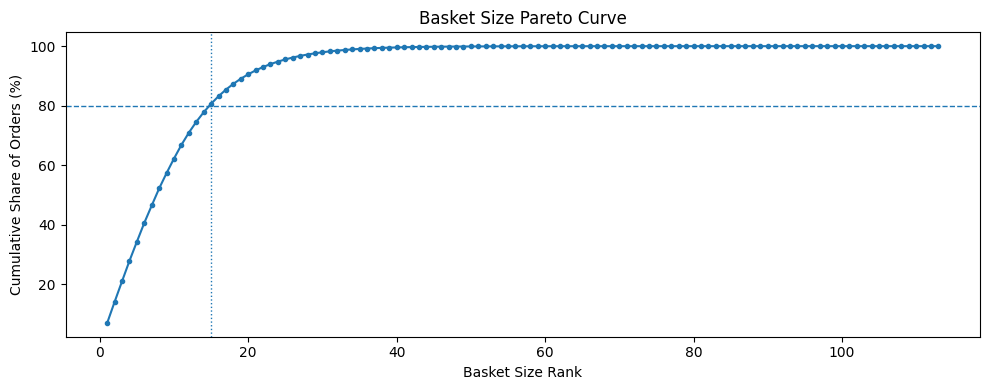

C:\Users\geeth\AppData\Local\Temp\ipykernel_10160\2726736819.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, conn)
C:\Users\geeth\AppData\Local\Temp\ipykernel_10160\2726736819.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, conn)
C:\Users\geeth\AppData\Local\Temp\ipykernel_10160\2726736819.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(query, conn)


,product_name,total_orders,rank,share_pct,cum_share_pct
0,Banana,472565,1,1.456983,1.456983
1,Bag of Organic Bananas,379450,2,1.169897,2.626880
2,Organic Strawberries,264683,3,0.816054,3.442934
3,Organic Baby Spinach,241921,4,0.745876,4.188810
4,Organic Hass Avocado,213584,5,0.658509,4.847319
5,Organic Avocado,176815,6,0.545145,5.392464
6,Large Lemon,152657,7,0.470663,5.863126
7,Strawberries,142951,8,0.440738,6.303864
8,Limes,140627,9,0.433572,6.737436
9,Organic Whole Milk,137905,10,0.425180,7.162616


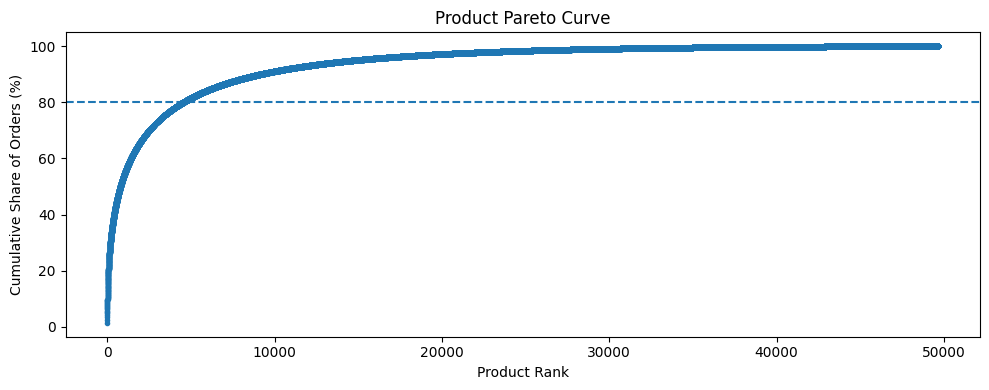

,department,total_orders,rank,share_pct,cum_share_pct
0,produce,9479291,1,29.225961,29.225961
1,dairy eggs,5414016,2,16.692158,45.918118
2,snacks,2887550,3,8.902715,54.820833
3,beverages,2690129,4,8.294038,63.114871
4,frozen,2236432,5,6.895228,70.010099
5,pantry,1875577,6,5.782662,75.792762
6,bakery,1176787,7,3.628197,79.420958
7,canned goods,1068058,8,3.292970,82.713928
8,deli,1051249,9,3.241146,85.955074
9,dry goods pasta,866627,10,2.671930,88.627004


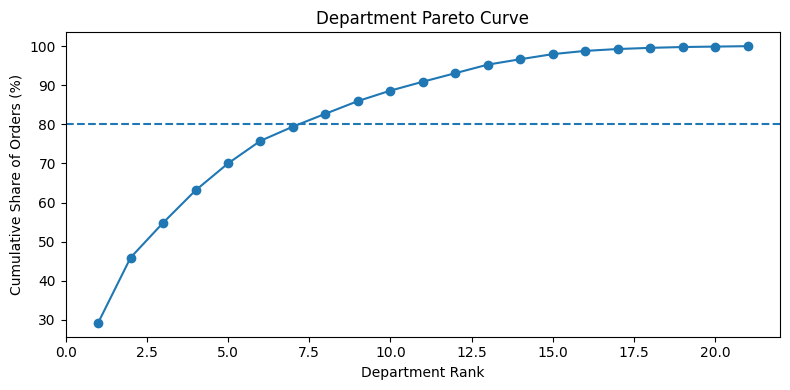

,order_hour_of_day,total_orders,rank,share_pct,cum_share_pct
0,10,271885,1,8.457097,8.457097
1,11,268006,2,8.336439,16.793535
2,15,266132,3,8.278147,25.071682
3,14,265556,4,8.260230,33.331913
4,13,261174,5,8.123926,41.455839
5,12,256206,6,7.969395,49.425234
6,16,255949,7,7.961401,57.386635
7,9,243496,8,7.574045,64.960680
8,17,214080,9,6.659048,71.619728
9,18,170998,10,5.318964,76.938692


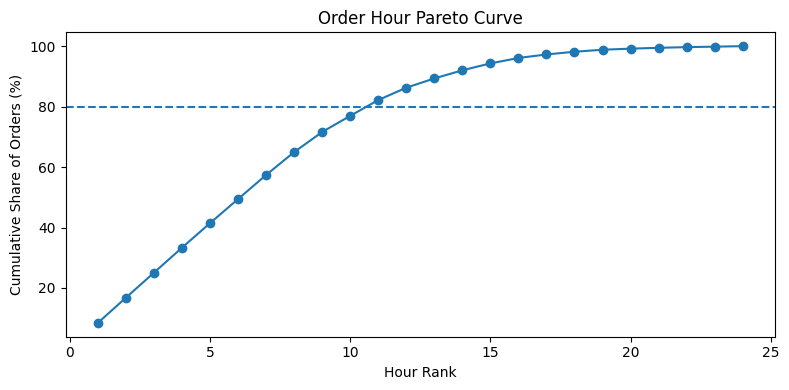

,dimension,groups_needed_for_80pct,total_groups,pct_groups_needed
0,Products,4538,49677,9.135012
3,Basket Sizes,15,113,13.274336
1,Departments,8,21,38.095238
2,Order Hours,11,24,45.833333


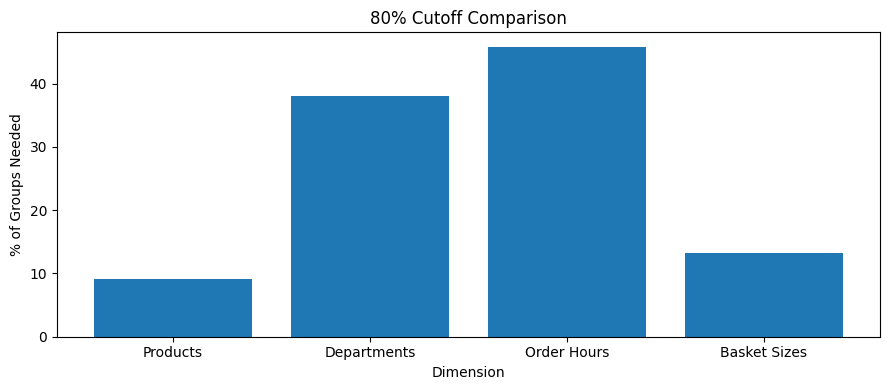

In [11]:
# 1) Reorder vs Non-Reorder Split
reorder_split_df = run_sql("""
SELECT
  CASE WHEN reordered = 1 THEN 'Reordered' ELSE 'First-time / Not Reordered' END AS reorder_type,
  total_count
FROM mv_reorder_rate
ORDER BY reordered DESC
""")
reorder_split_df["share_pct"] = 100.0 * reorder_split_df["total_count"] / reorder_split_df["total_count"].sum()
display(reorder_split_df)

plt.figure(figsize=(6, 6))
plt.pie(
    reorder_split_df["total_count"],
    labels=reorder_split_df["reorder_type"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"linewidth": 1, "edgecolor": "white"},
)
plt.title("Reorder vs Non-Reorder Split")
plt.tight_layout()
plt.show()

# 2) Reorder Rate by Hour
reorder_rate_hour_df = run_sql("""
SELECT
  order_hour_of_day,
  total_orders,
  reorder_count,
  ROUND(100.0 * reorder_rate, 2) AS reorder_rate_pct
FROM mv_reorder_time_v2
ORDER BY order_hour_of_day
""")
display(reorder_rate_hour_df)

plt.figure(figsize=(10, 4))
plt.plot(reorder_rate_hour_df["order_hour_of_day"], reorder_rate_hour_df["reorder_rate_pct"], marker="o")
plt.title("Reorder Rate by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Reorder Rate (%)")
plt.tight_layout()
plt.show()

# 3) Top 15 Products by Reorder Count
top_reordered_products_df = run_sql("""
SELECT product_name, reorder_count, total_orders, reorder_rate
FROM mv_reorder_product_v2
ORDER BY reorder_count DESC
LIMIT 15
""")
display(top_reordered_products_df)

plot_top_prod = top_reordered_products_df.sort_values("reorder_count", ascending=True)
plt.figure(figsize=(10, 6))
plt.barh(plot_top_prod["product_name"], plot_top_prod["reorder_count"])
plt.title("Top 15 Products by Reorder Count")
plt.xlabel("Reorder Count")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

# 4) Product Loyalty Band Distribution
product_loyalty_summary_df = run_sql("""
SELECT
    product_loyalty_band,
    COUNT(*) AS product_count,
    ROUND(AVG(reorder_rate_pct), 2) AS avg_reorder_rate_pct,
    SUM(total_orders) AS total_orders
FROM (
    SELECT
        product_id,
        total_orders,
        ROUND(reorder_rate * 100, 2) AS reorder_rate_pct,
        CASE
            WHEN reorder_rate >= 0.75 AND total_orders >= 500 THEN 'Champion Product'
            WHEN reorder_rate >= 0.60 AND total_orders >= 200 THEN 'Loyal Product'
            WHEN reorder_rate >= 0.45 AND total_orders >= 100 THEN 'Potential Loyal Product'
            ELSE 'Low Loyalty Product'
        END AS product_loyalty_band
    FROM mv_reorder_product_v2
) p
GROUP BY product_loyalty_band
ORDER BY product_count DESC
""")
display(product_loyalty_summary_df)

plt.figure(figsize=(9, 4))
plt.bar(product_loyalty_summary_df["product_loyalty_band"], product_loyalty_summary_df["product_count"])
plt.title("Product Loyalty Band Distribution")
plt.xlabel("Product Loyalty Band")
plt.ylabel("Number of Products")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# 5) Department Loyalty Comparison
dept_loyalty_df = run_sql("""
SELECT
  department,
  total_orders,
  reorder_count,
  ROUND(100.0 * reorder_rate, 2) AS reorder_rate_pct
FROM mv_reorder_department_v2
ORDER BY reorder_rate DESC, total_orders DESC
""")
display(dept_loyalty_df)

plot_dept_loyalty = dept_loyalty_df.sort_values("reorder_rate_pct", ascending=True)
plt.figure(figsize=(10, 6))
plt.barh(plot_dept_loyalty["department"], plot_dept_loyalty["reorder_rate_pct"])
plt.title("Department Loyalty Comparison")
plt.xlabel("Reorder Rate (%)")
plt.ylabel("Department")
plt.tight_layout()
plt.show()

# 6) Department Action Matrix: Volume vs Loyalty Gap
dept_action_viz_df = run_sql("""
SELECT department, total_orders, reorder_rate
FROM mv_reorder_department_v2
""")
dept_action_viz_df["order_share_pct"] = 100.0 * dept_action_viz_df["total_orders"] / dept_action_viz_df["total_orders"].sum()
benchmark = dept_action_viz_df["reorder_rate"].mean()
dept_action_viz_df["gap_to_benchmark"] = dept_action_viz_df["reorder_rate"] - benchmark
median_order_share = dept_action_viz_df["order_share_pct"].median()


def assign_action(row):
    high_volume = row["order_share_pct"] >= median_order_share
    low_loyalty = row["gap_to_benchmark"] < 0
    if high_volume and not low_loyalty:
        return "Defend"
    if high_volume and low_loyalty:
        return "Fix First"
    if (not high_volume) and not low_loyalty:
        return "Grow Selectively"
    return "Niche Monitor"


dept_action_viz_df["action_segment"] = dept_action_viz_df.apply(assign_action, axis=1)
display(dept_action_viz_df[["department", "total_orders", "order_share_pct", "reorder_rate", "gap_to_benchmark", "action_segment"]])

color_map = {
    "Defend": "#1f77b4",
    "Fix First": "#d62728",
    "Grow Selectively": "#2ca02c",
    "Niche Monitor": "#ff7f0e",
}

plt.figure(figsize=(10, 6))
for seg, part in dept_action_viz_df.groupby("action_segment"):
    plt.scatter(
        part["order_share_pct"],
        part["gap_to_benchmark"],
        s=80,
        alpha=0.85,
        label=seg,
        c=color_map.get(seg, "#7f7f7f"),
    )

for _, r in dept_action_viz_df.iterrows():
    plt.annotate(r["department"], (r["order_share_pct"], r["gap_to_benchmark"]), fontsize=8, alpha=0.9)

plt.axvline(median_order_share, linestyle="--", linewidth=1)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Department Action Matrix: Volume vs Loyalty Gap")
plt.xlabel("Order Share (%)")
plt.ylabel("Reorder Rate Gap vs Benchmark")
plt.legend(title="Action Segment")
plt.tight_layout()
plt.show()

# 7) Low-Loyalty High-Volume Priorities
priority_low_loyalty_df = (
    dept_action_viz_df[dept_action_viz_df["action_segment"] == "Fix First"]
    .sort_values(["order_share_pct", "gap_to_benchmark"], ascending=[False, True])
    [["department", "total_orders", "order_share_pct", "reorder_rate", "gap_to_benchmark", "action_segment"]]
    .reset_index(drop=True)
)
display(priority_low_loyalty_df)

# 8) Basket Summary
basket_df = run_sql("SELECT order_id, basket_size FROM mv_basket_analysis_v2")
basket_summary_df = pd.DataFrame(
    {
        "metric": [
            "total_orders",
            "avg_basket_size",
            "median_basket_size",
            "p75_basket_size",
            "p90_basket_size",
            "max_basket_size",
        ],
        "value": [
            int(basket_df["order_id"].nunique()),
            round(float(basket_df["basket_size"].mean()), 2),
            round(float(basket_df["basket_size"].median()), 2),
            round(float(basket_df["basket_size"].quantile(0.75)), 2),
            round(float(basket_df["basket_size"].quantile(0.90)), 2),
            int(basket_df["basket_size"].max()),
        ],
    }
)
display(basket_summary_df)

# 9) Basket Size Distribution
basket_distribution_df = (
    basket_df.groupby("basket_size", as_index=False)
    .agg(order_count=("order_id", "count"))
    .sort_values("basket_size")
)
display(basket_distribution_df.head(30))

plt.figure(figsize=(10, 4))
plot_dist = basket_distribution_df[basket_distribution_df["basket_size"] <= basket_distribution_df["basket_size"].quantile(0.95)]
plt.plot(plot_dist["basket_size"], plot_dist["order_count"], marker="o")
plt.title("Basket Size Distribution")
plt.xlabel("Basket Size")
plt.ylabel("Order Count")
plt.tight_layout()
plt.show()

# 10) Order Share by Basket Segment
basket_segment_df = run_sql("""
WITH b AS (
    SELECT
        order_id,
        basket_size,
        CASE
            WHEN basket_size <= 5 THEN 'Small (1-5 items)'
            WHEN basket_size <= 15 THEN 'Medium (6-15 items)'
            ELSE 'Large (16+ items)'
        END AS basket_segment
    FROM mv_basket_analysis_v2
)
SELECT
    basket_segment,
    COUNT(*) AS order_count,
    ROUND(AVG(basket_size), 2) AS avg_basket_size,
    SUM(basket_size) AS total_items,
    ROUND(100.0 * COUNT(*)::numeric / SUM(COUNT(*)) OVER (), 2) AS order_share_pct,
    ROUND(100.0 * SUM(basket_size)::numeric / SUM(SUM(basket_size)) OVER (), 2) AS item_share_pct
FROM b
GROUP BY basket_segment
ORDER BY avg_basket_size
""")
display(basket_segment_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(basket_segment_df["basket_segment"], basket_segment_df["order_share_pct"])
axes[0].set_title("Order Share by Basket Segment")
axes[0].set_xlabel("Basket Segment")
axes[0].set_ylabel("Order Share (%)")
axes[0].tick_params(axis="x", rotation=15)

axes[1].bar(basket_segment_df["basket_segment"], basket_segment_df["item_share_pct"])
axes[1].set_title("Item Share by Basket Segment")
axes[1].set_xlabel("Basket Segment")
axes[1].set_ylabel("Item Share (%)")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

# 11) Basket Size Pareto Curve
basket_pareto_viz_df = run_sql("""
SELECT basket_size, COUNT(*) AS order_count
FROM mv_basket_analysis_v2
GROUP BY basket_size
""")
basket_pareto_viz_df = basket_pareto_viz_df.sort_values("order_count", ascending=False).reset_index(drop=True)
basket_pareto_viz_df["rank"] = basket_pareto_viz_df.index + 1
basket_pareto_viz_df["share_pct"] = 100.0 * basket_pareto_viz_df["order_count"] / basket_pareto_viz_df["order_count"].sum()
basket_pareto_viz_df["cum_share_pct"] = basket_pareto_viz_df["share_pct"].cumsum()
basket_cutoff_rank = int(basket_pareto_viz_df.loc[basket_pareto_viz_df["cum_share_pct"] >= 80.0, "rank"].iloc[0])
display(basket_pareto_viz_df.head(20))

plt.figure(figsize=(10, 4))
plt.plot(basket_pareto_viz_df["rank"], basket_pareto_viz_df["cum_share_pct"], marker=".")
plt.axhline(80, linestyle="--", linewidth=1)
plt.axvline(basket_cutoff_rank, linestyle=":", linewidth=1)
plt.title("Basket Size Pareto Curve")
plt.xlabel("Basket Size Rank")
plt.ylabel("Cumulative Share of Orders (%)")
plt.tight_layout()
plt.show()

# 12) Product Pareto Curve

def build_pareto(df: pd.DataFrame, group_col: str, value_col: str) -> pd.DataFrame:
    p = df[[group_col, value_col]].copy()
    p[value_col] = pd.to_numeric(p[value_col], errors="coerce")
    p = p.dropna(subset=[value_col])
    p = p.groupby(group_col, as_index=False)[value_col].sum()
    p = p.sort_values(value_col, ascending=False).reset_index(drop=True)
    p["rank"] = p.index + 1
    p["share_pct"] = 100.0 * p[value_col] / p[value_col].sum()
    p["cum_share_pct"] = p["share_pct"].cumsum()
    return p

product_pareto = build_pareto(run_sql("SELECT product_name, total_orders FROM mv_product_performance_v2"), "product_name", "total_orders")
department_pareto = build_pareto(run_sql("SELECT department, total_orders FROM mv_department_performance_v2"), "department", "total_orders")
hour_pareto = build_pareto(run_sql("SELECT order_hour_of_day, total_orders FROM mv_orders_time_v2"), "order_hour_of_day", "total_orders")

display(product_pareto.head(20))

plt.figure(figsize=(10, 4))
plt.plot(product_pareto["rank"], product_pareto["cum_share_pct"], marker=".")
plt.axhline(80, linestyle="--")
plt.title("Product Pareto Curve")
plt.xlabel("Product Rank")
plt.ylabel("Cumulative Share of Orders (%)")
plt.tight_layout()
plt.show()

# 13) Department Pareto Curve
display(department_pareto)

plt.figure(figsize=(8, 4))
plt.plot(department_pareto["rank"], department_pareto["cum_share_pct"], marker="o")
plt.axhline(80, linestyle="--")
plt.title("Department Pareto Curve")
plt.xlabel("Department Rank")
plt.ylabel("Cumulative Share of Orders (%)")
plt.tight_layout()
plt.show()

# 14) Order Hour Pareto Curve
display(hour_pareto)

plt.figure(figsize=(8, 4))
plt.plot(hour_pareto["rank"], hour_pareto["cum_share_pct"], marker="o")
plt.axhline(80, linestyle="--")
plt.title("Order Hour Pareto Curve")
plt.xlabel("Hour Rank")
plt.ylabel("Cumulative Share of Orders (%)")
plt.tight_layout()
plt.show()

# 15) 80% Cutoff Comparison
def cutoff_rank(df: pd.DataFrame, threshold: float = 80.0) -> int:
    return int(df.loc[df["cum_share_pct"] >= threshold, "rank"].iloc[0])

cutoff_compare_df = pd.DataFrame(
    {
        "dimension": ["Products", "Departments", "Order Hours", "Basket Sizes"],
        "groups_needed_for_80pct": [
            cutoff_rank(product_pareto),
            cutoff_rank(department_pareto),
            cutoff_rank(hour_pareto),
            basket_cutoff_rank,
        ],
        "total_groups": [
            int(len(product_pareto)),
            int(len(department_pareto)),
            int(len(hour_pareto)),
            int(len(basket_pareto_viz_df)),
        ],
    }
)
cutoff_compare_df["pct_groups_needed"] = 100.0 * cutoff_compare_df["groups_needed_for_80pct"] / cutoff_compare_df["total_groups"]
display(cutoff_compare_df.sort_values("pct_groups_needed"))

plt.figure(figsize=(9, 4))
plt.bar(cutoff_compare_df["dimension"], cutoff_compare_df["pct_groups_needed"])
plt.title("80% Cutoff Comparison")
plt.ylabel("% of Groups Needed")
plt.xlabel("Dimension")
plt.tight_layout()
plt.show()